In [1]:
#Osnovne biblioteke

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib.ticker import FuncFormatter
from collections import Counter
from scipy.stats import randint
from pathlib import Path


In [2]:
#Scikit-learn – pipeline i transformacije

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    QuantileTransformer,
    FunctionTransformer,
    StandardScaler
)
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

In [3]:
#Scikit-learn – modeli

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    RidgeCV,
    Lasso,
    ElasticNet
)
from sklearn.ensemble import (
    RandomForestRegressor,
    StackingRegressor
)
from sklearn.neural_network import MLPRegressor

In [4]:
#Scikit-learn – evaluacija, metrika i 

from sklearn.model_selection import (
    train_test_split,
    cross_val_predict,
    KFold,
    GridSearchCV,
    RandomizedSearchCV,
    learning_curve
)
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_squared_log_error,
    make_scorer
)
from sklearn.inspection import permutation_importance

In [5]:
#Boosting modeli

import xgboost as xgb
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [6]:
current_directory = str(Path.cwd())
print(current_directory)

C:\Users\aleks\Sberbank\Sberbank-House-Pricing


In [7]:
data = pd.read_csv(current_directory+"/train.csv")
df = pd.DataFrame(data)
pd.set_option('display.max_columns', 300)
pd.set_option('display.max_rows', 300)

In [8]:
df.head()

,id,timestamp,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,state,product_type,sub_area,area_m,raion_popul,green_zone_part,indust_part,children_preschool,preschool_quota,preschool_education_centers_raion,children_school,school_quota,school_education_centers_raion,school_education_centers_top_20_raion,hospital_beds_raion,healthcare_centers_raion,university_top_20_raion,sport_objects_raion,additional_education_raion,culture_objects_top_25,culture_objects_top_25_raion,shopping_centers_raion,office_raion,thermal_power_plant_raion,incineration_raion,oil_chemistry_raion,radiation_raion,railroad_terminal_raion,big_market_raion,nuclear_reactor_raion,detention_facility_raion,full_all,male_f,female_f,young_all,young_male,young_female,work_all,work_male,work_female,ekder_all,ekder_male,ekder_female,0_6_all,0_6_male,0_6_female,7_14_all,7_14_male,7_14_female,0_17_all,0_17_male,0_17_female,16_29_all,16_29_male,16_29_female,0_13_all,0_13_male,0_13_female,raion_build_count_with_material_info,build_count_block,build_count_wood,build_count_frame,build_count_brick,build_count_monolith,build_count_panel,build_count_foam,build_count_slag,build_count_mix,raion_build_count_with_builddate_info,build_count_before_1920,build_count_1921-1945,build_count_1946-1970,build_count_1971-1995,build_count_after_1995,ID_metro,metro_min_avto,metro_km_avto,metro_min_walk,metro_km_walk,kindergarten_km,school_km,park_km,green_zone_km,industrial_km,water_treatment_km,cemetery_km,incineration_km,railroad_station_walk_km,railroad_station_walk_min,ID_railroad_station_walk,railroad_station_avto_km,railroad_station_avto_min,ID_railroad_station_avto,public_transport_station_km,public_transport_station_min_walk,water_km,water_1line,mkad_km,ttk_km,sadovoe_km,bulvar_ring_km,kremlin_km,big_road1_km,ID_big_road1,big_road1_1line,big_road2_km,ID_big_road2,railroad_km,railroad_1line,zd_vokzaly_avto_km,ID_railroad_terminal,bus_terminal_avto_km,ID_bus_terminal,oil_chemistry_km,nuclear_reactor_km,radiation_km,power_transmission_line_km,thermal_power_plant_km,ts_km,big_market_km,market_shop_km,fitness_km,swim_pool_km,ice_rink_km,stadium_km,basketball_km,hospice_morgue_km,detention_facility_km,public_healthcare_km,university_km,workplaces_km,shopping_centers_km,office_km,additional_education_km,preschool_km,big_church_km,church_synagogue_km,mosque_km,theater_km,museum_km,exhibition_km,catering_km,ecology,green_part_500,prom_part_500,office_count_500,office_sqm_500,trc_count_500,trc_sqm_500,cafe_count_500,cafe_sum_500_min_price_avg,cafe_sum_500_max_price_avg,cafe_avg_price_500,cafe_count_500_na_price,cafe_count_500_price_500,cafe_count_500_price_1000,cafe_count_500_price_1500,cafe_count_500_price_2500,cafe_count_500_price_4000,cafe_count_500_price_high,big_church_count_500,church_count_500,mosque_count_500,leisure_count_500,sport_count_500,market_count_500,green_part_1000,prom_part_1000,office_count_1000,office_sqm_1000,trc_count_1000,trc_sqm_1000,cafe_count_1000,cafe_sum_1000_min_price_avg,cafe_sum_1000_max_price_avg,cafe_avg_price_1000,cafe_count_1000_na_price,cafe_count_1000_price_500,cafe_count_1000_price_1000,cafe_count_1000_price_1500,cafe_count_1000_price_2500,cafe_count_1000_price_4000,cafe_count_1000_price_high,big_church_count_1000,church_count_1000,mosque_count_1000,leisure_count_1000,sport_count_1000,market_count_1000,green_part_1500,prom_part_1500,office_count_1500,office_sqm_1500,trc_count_1500,trc_sqm_1500,cafe_count_1500,cafe_sum_1500_min_price_avg,cafe_sum_1500_max_price_avg,cafe_avg_price_1500,cafe_count_1500_na_price,cafe_count_1500_price_500,cafe_count_1500_price_1000,cafe_count_1500_price_1500,cafe_count_1500_price_2500,cafe_count_1500_price_4000,cafe_count_1500_price_high,big_church_count_1500,church_count_1500,mosque_count_1500,leisure_count_1500,sport_count_1500,market_count_1500,green_part_2000,prom_part_2000,office_count_2000,office_sqm_2000,trc_count_2000,trc_sqm_2000,cafe_count_2000,cafe_sum_2000_min_price_avg,cafe_sum_2000_max_price_av

In [9]:
print(df.dtypes.unique())

[dtype('int64') dtype('O') dtype('float64')]


In [10]:
df.drop(columns=['id'], inplace=True)

In [11]:
df.shape

(30471, 291)

In [12]:
# prag za periferiju (npr. stanovi dalje od 30 km od Kremlja)
df = df[df["kremlin_km"] <= 30].copy()

In [13]:
target = df["price_doc"]
print(target.isna().sum())

0


In [14]:
print(df["price_doc"].head())
print(df["price_doc"].min(), df["price_doc"].max())

0     5850000
1     6000000
2     5700000
3    13100000
4    16331452
Name: price_doc, dtype: int64
100000 111111112


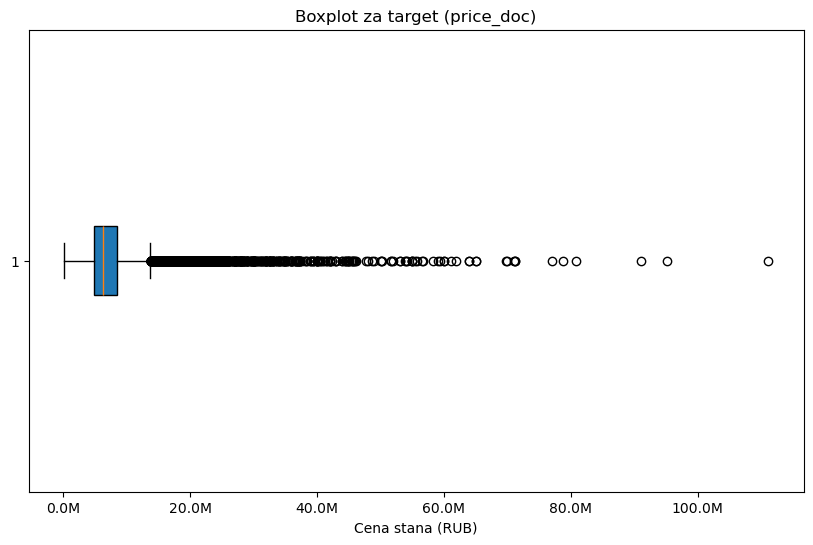

In [15]:

plt.figure(figsize=(10,6))
plt.boxplot(df["price_doc"], vert=False, patch_artist=True)

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.title("Boxplot za target (price_doc)")
plt.xlabel("Cena stana (RUB)")
plt.show()

In [16]:
#df = df.sample(n=10000, random_state=42)

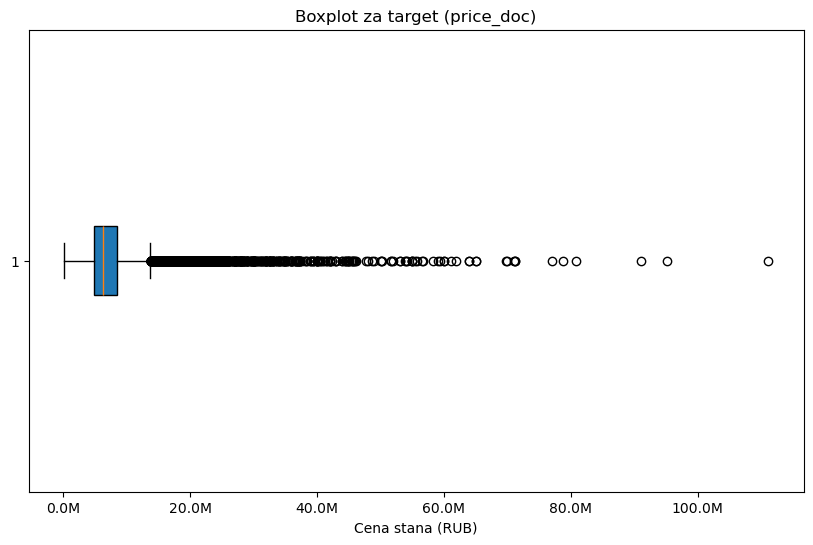

In [17]:
plt.figure(figsize=(10,6))
plt.boxplot(df["price_doc"], vert=False, patch_artist=True)

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.title("Boxplot za target (price_doc)")
plt.xlabel("Cena stana (RUB)")
plt.show()

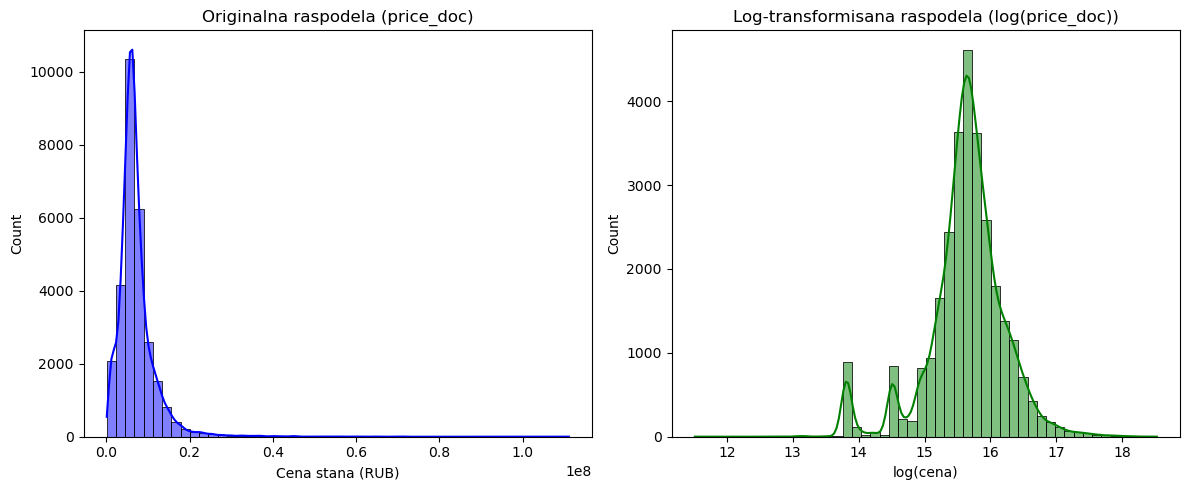

In [18]:
# originalni target
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df["price_doc"], kde=True, bins=50, color="blue")
plt.title("Originalna raspodela (price_doc)")
plt.xlabel("Cena stana (RUB)")

# log-transformisani target
plt.subplot(1,2,2)
sns.histplot(np.log1p(df["price_doc"]), kde=True, bins=50, color="green")
plt.title("Log-transformisana raspodela (log(price_doc))")
plt.xlabel("log(cena)")

plt.tight_layout()
plt.show()

In [19]:
new_cols = []

In [20]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
start = df["timestamp"].min()

df["year"] = df["timestamp"].dt.year
df["month"] = df["timestamp"].dt.month

df.drop(columns=['timestamp'], inplace=True)
new_cols.extend(["year","month"])

In [21]:
df.shape

(28906, 292)

In [22]:
df["floor_ratio"] = df.apply(
    lambda row: row["floor"] / row["max_floor"] if pd.notnull(row["max_floor"]) and row["max_floor"] > 0 else 0,
    axis=1
)

In [23]:
df["build_age"] = df["year"] - df["build_year"]
new_cols.extend(["floor_ratio","build_age"])

In [24]:
df.shape

(28906, 294)

In [25]:
cols = [c for c in df.columns if c != 'price_doc'] + ['price_doc']
df = df[cols]

In [26]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [27]:
print(y.name)

price_doc


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [29]:
y_train.head()

6941     5796000
12866    6095313
604      5800000
12523    3000000
6467     6517253
Name: price_doc, dtype: int64

In [301]:
"""Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mask = (y_train >= lower_bound) & (y_train <= upper_bound)

X_train = X_train.loc[mask]
y_train = y_train.loc[mask]"""

lower = y_train.quantile(0.1)
upper = y_train.quantile(0.9)

mask = (y_train >= lower) & (y_train <= upper)

X_train_clean = X_train.loc[mask]
y_train_clean = y_train.loc[mask]

In [31]:
print(y_train.isna().sum().sum())
print(y_test.isna().sum().sum())

0
0


In [297]:
df = df.dropna(subset=["price_doc"]).copy()

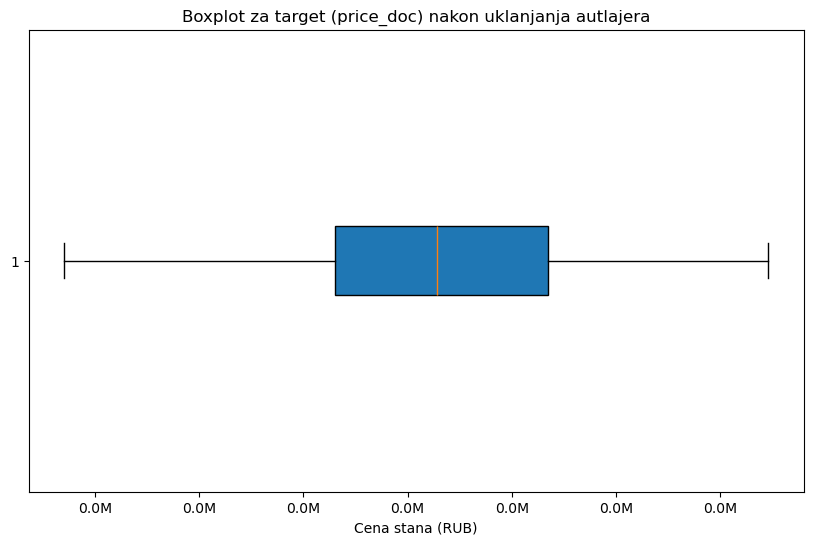

In [303]:
plt.figure(figsize=(10,6))
plt.boxplot(y_train_clean, vert=False, patch_artist=True)

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.title("Boxplot za target (price_doc) nakon uklanjanja autlajera")
plt.xlabel("Cena stana (RUB)")
plt.show()

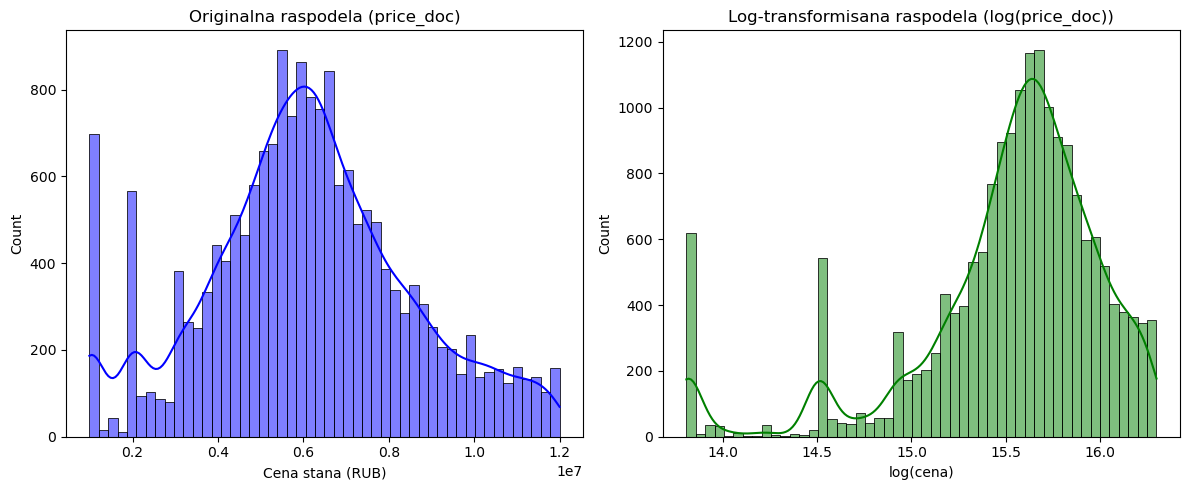

In [34]:
# originalni target
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(y_train_clean, kde=True, bins=50, color="blue")
plt.title("Originalna raspodela (price_doc)")
plt.xlabel("Cena stana (RUB)")

# log-transformisani target
plt.subplot(1,2,2)
sns.histplot(np.log1p(y_train_clean), kde=True, bins=50, color="green")
plt.title("Log-transformisana raspodela (log(price_doc))")
plt.xlabel("log(cena)")

plt.tight_layout()
plt.show()

In [35]:
df["price_doc_log"] = np.log1p(df["price_doc"])

In [36]:
y_train_clean = np.log1p(y_train_clean)

### Test

In [38]:
def missing_values_ratio(df, ratio_for_na_values=0.3, target_col="price_doc", corr_threshold=0.4):
    # 1. Missing ratio for each column
    missing_ratio = df.isnull().mean().sort_values(ascending=False)
    
    # 2. Select only columns with > threshold % missing
    cols_over_n = missing_ratio[missing_ratio > ratio_for_na_values]
    cols_to_drop = []
    
    if not cols_over_n.empty:
        print(f"Kolone sa preko {round(ratio_for_na_values*100)}% nedostajućih vrednosti:\n")
        
        # 3. For each such column, compute correlation with target
        for col in cols_over_n.index:
            if df[col].dtype in ['int64', 'float64']:  # only numeric can correlate
                corr_val = df[[col, target_col]].corr().iloc[0, 1]  # correlation col <-> target
                if (corr_val is None) or (abs(corr_val) < corr_threshold):
                    cols_to_drop.append(col)
                print(f"{col}: {cols_over_n[col]*100:.2f}% NaN, korelacija sa targetom = {corr_val:.3f}")
        return cols_to_drop
    else:
        print("Nema takvih kolona")
        return []

In [39]:
columns_to_drop = missing_values_ratio(df, 0.3, "price_doc", 0.4)

Kolone sa preko 30% nedostajućih vrednosti:

hospital_beds_raion: 46.71% NaN, korelacija sa targetom = 0.140
build_year: 44.75% NaN, korelacija sa targetom = 0.002
build_age: 44.75% NaN, korelacija sa targetom = -0.002
state: 44.53% NaN, korelacija sa targetom = 0.119
cafe_sum_500_min_price_avg: 41.63% NaN, korelacija sa targetom = 0.033
cafe_avg_price_500: 41.63% NaN, korelacija sa targetom = 0.034
cafe_sum_500_max_price_avg: 41.63% NaN, korelacija sa targetom = 0.034
max_floor: 31.93% NaN, korelacija sa targetom = 0.083
material: 31.93% NaN, korelacija sa targetom = 0.066
num_room: 31.93% NaN, korelacija sa targetom = 0.483
kitch_sq: 31.93% NaN, korelacija sa targetom = 0.037


In [40]:
print(columns_to_drop)

['hospital_beds_raion', 'build_year', 'build_age', 'state', 'cafe_sum_500_min_price_avg', 'cafe_avg_price_500', 'cafe_sum_500_max_price_avg', 'max_floor', 'material', 'kitch_sq']


In [41]:
X_test = X_test.drop(columns=columns_to_drop)  
X_train = X_train_clean.drop(columns=columns_to_drop) 

In [42]:
X_train.shape, X_test.shape

((18216, 283), (8672, 283))

In [43]:
train_imputer = SimpleImputer

In [44]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

In [45]:
train_num = X_train[num_cols].copy()
train_cat = X_train[cat_cols].copy()

In [46]:
train_num.shape, train_cat.shape

((18216, 266), (18216, 15))

In [47]:
for cat in cat_cols:
    print(cat)
    print(train_cat[cat].unique())

product_type
['OwnerOccupier' 'Investment']
sub_area
['Poselenie Sosenskoe' "Tekstil'shhiki" 'Levoberezhnoe' 'Strogino'
 'Pokrovskoe Streshnevo' 'Beskudnikovskoe' 'Tverskoe' 'Jasenevo'
 "Gol'janovo" 'Filevskij Park' 'Marfino' 'Danilovskoe'
 'Juzhnoe Medvedkovo' 'Mitino' 'Ljublino' 'Cheremushki' 'Vojkovskoe'
 'Kuncevo' 'Birjulevo Zapadnoe' 'Sviblovo' 'Lianozovo' "Mar'ino"
 'Juzhnoe Butovo' 'Babushkinskoe' 'Severnoe Izmajlovo'
 "Moskvorech'e-Saburovo" 'Sokol' 'Dmitrovskoe' 'Novogireevo'
 'Poselenie Moskovskij' 'Lefortovo' 'Ochakovo-Matveevskoe' 'Perovo'
 "Chertanovo Central'noe" 'Veshnjaki' 'Ajeroport' 'Nekrasovka' 'Zjuzino'
 'Poselenie Vnukovskoe' 'Poselenie Voskresenskoe' 'Mozhajskoe'
 'Nagatino-Sadovniki' 'Zapadnoe Degunino' 'Poselenie Desjonovskoe'
 'Nagornoe' "Mar'ina Roshha" 'Bogorodskoe' "Kuz'minki" 'Ostankinskoe'
 'Kosino-Uhtomskoe' 'Severnoe Tushino' 'Jaroslavskoe'
 'Poselenie Filimonkovskoe' 'Obruchevskoe' 'Solncevo' 'Otradnoe'
 'Severnoe Medvedkovo' 'Novokosino' 'Vostochnoe Iz

In [48]:
ordinal_cols = ["ecology"] 
freq_cols = ["sub_area"]
nominal_cols = [col for col in cat_cols if col not in ordinal_cols + freq_cols]

In [49]:
print(nominal_cols)

['product_type', 'culture_objects_top_25', 'thermal_power_plant_raion', 'incineration_raion', 'oil_chemistry_raion', 'radiation_raion', 'railroad_terminal_raion', 'big_market_raion', 'nuclear_reactor_raion', 'detention_facility_raion', 'water_1line', 'big_road1_1line', 'railroad_1line']


In [50]:
train_cat["ecology"] = train_cat["ecology"].replace("no data", np.nan)
train_cat = train_cat.replace(["nan", "NaN", ""], np.nan)
imputer = SimpleImputer(strategy="most_frequent").set_output(transform="pandas")
train_cat = imputer.fit_transform(train_cat)

In [51]:
train_cat.isna().sum().sum()

0

In [52]:
imputer_num = SimpleImputer(strategy="median").set_output(transform="pandas")
train_num = imputer.fit_transform(train_num)

train_num.isna().sum().sum()

0

In [53]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None, normalize=True):
        self.columns = columns
        self.normalize = normalize
        self.freq_maps = {}

    def fit(self, X, y=None):
        for col in self.columns:
            self.freq_maps[col] = X[col].value_counts(normalize=self.normalize)
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.columns:
            X[col] = X[col].map(self.freq_maps[col]).fillna(0)
        return X

In [54]:
def categorical_to_numeric(df_obj, nominal_cols, ordinal_cols, freq_cols):
    if freq_cols:
        fe = FrequencyEncoder(columns=freq_cols, normalize=True)
        df_obj[freq_cols] = fe.fit_transform(df_obj[freq_cols])


    if nominal_cols:
        ohe = OneHotEncoder(drop="if_binary", sparse_output=False, handle_unknown="ignore")
        df_encoded = pd.DataFrame(
            ohe.fit_transform(df_obj[nominal_cols]),
            columns=ohe.get_feature_names_out(nominal_cols),
            index=df_obj.index
        )
        df_obj = df_obj.drop(columns=nominal_cols)
        df_obj = pd.concat([df_obj, df_encoded], axis=1)

    if ordinal_cols:
        order = [["excellent", "good", "satisfactory", "poor"]]
        enc = OrdinalEncoder(categories=order)
        for col in ordinal_cols:
            df_obj[col] = enc.fit_transform(df_obj[[col]])

    return df_obj

In [55]:
train_cat_to_num = categorical_to_numeric(train_cat, nominal_cols, ordinal_cols, freq_cols)

In [56]:
train_cat_to_num.shape

(18216, 15)

In [57]:
train_cat_with_target = train_cat_to_num.copy()
train_cat_with_target['price_doc'] = y_train 

corr = train_cat_with_target.corr()["price_doc"].sort_values(ascending=False)
print(corr[(corr >= 0.25) | (corr <= -0.25)])

price_doc    1.0
Name: price_doc, dtype: float64


In [58]:
def columns_selector(train_num_with_target, corr_treshold = 0.25):
    
    corr_matrix = train_num_with_target.corr(numeric_only=True)
    target_corr = corr_matrix["price_doc"].drop("price_doc")
    selected_features = target_corr[target_corr.abs() > corr_treshold].index.tolist()
    
    print(f"Feature-i sa korelacijom > {corr_treshold} sa targetom:")
    print(selected_features)

    return selected_features

Feature-i sa korelacijom > 0.11 sa targetom:
['sub_area', 'product_type_OwnerOccupier']


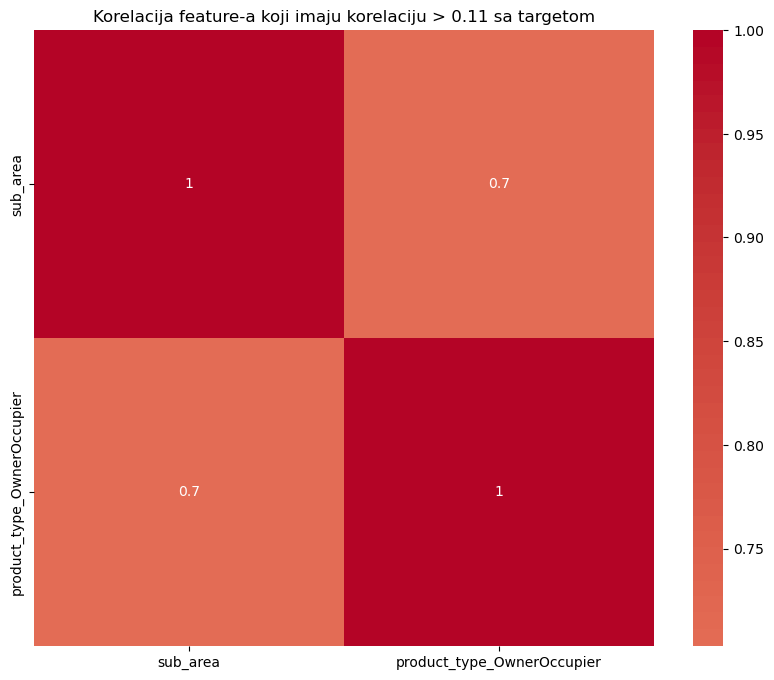

In [59]:
corr_treshold = 0.11
selected_features = columns_selector(train_cat_with_target, corr_treshold = corr_treshold)
plt.figure(figsize=(10,8))
sns.heatmap(train_cat_with_target[selected_features].corr(), annot=True, cmap="coolwarm", center=0)
plt.title(f"Korelacija feature-a koji imaju korelaciju > {corr_treshold} sa targetom")
plt.show()

In [60]:
train_cat_to_num.head()

,sub_area,ecology,product_type_OwnerOccupier,culture_objects_top_25_yes,thermal_power_plant_raion_yes,incineration_raion_yes,oil_chemistry_raion_yes,radiation_raion_yes,railroad_terminal_raion_yes,big_market_raion_yes,nuclear_reactor_raion_yes,detention_facility_raion_yes,water_1line_yes,big_road1_1line_yes,railroad_1line_yes
6941,0.067907,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
12866,0.011419,3.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
604,0.004007,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12523,0.009168,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6467,0.005380,2.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [61]:
train_num_with_target = train_num.copy()
train_num_with_target['price_doc'] = y_train 

corr = train_num_with_target.corr()["price_doc"].sort_values(ascending=False)
print(corr[(corr >= 0.2) | (corr <= -0.2)])

price_doc               1.000000
num_room                0.305180
park_km                -0.203226
sadovoe_km             -0.203416
zd_vokzaly_avto_km     -0.211830
ttk_km                 -0.212264
ts_km                  -0.214932
preschool_km           -0.216754
school_km              -0.217249
nuclear_reactor_km     -0.218065
basketball_km          -0.221430
fitness_km             -0.222188
workplaces_km          -0.228144
swim_pool_km           -0.232965
big_church_km          -0.243910
metro_min_avto         -0.248085
public_healthcare_km   -0.249542
metro_km_avto          -0.260275
metro_km_walk          -0.262744
metro_min_walk         -0.262744
Name: price_doc, dtype: float64


Feature-i sa korelacijom > 0.22 sa targetom:
['num_room', 'metro_min_avto', 'metro_km_avto', 'metro_min_walk', 'metro_km_walk', 'fitness_km', 'swim_pool_km', 'basketball_km', 'public_healthcare_km', 'workplaces_km', 'big_church_km']


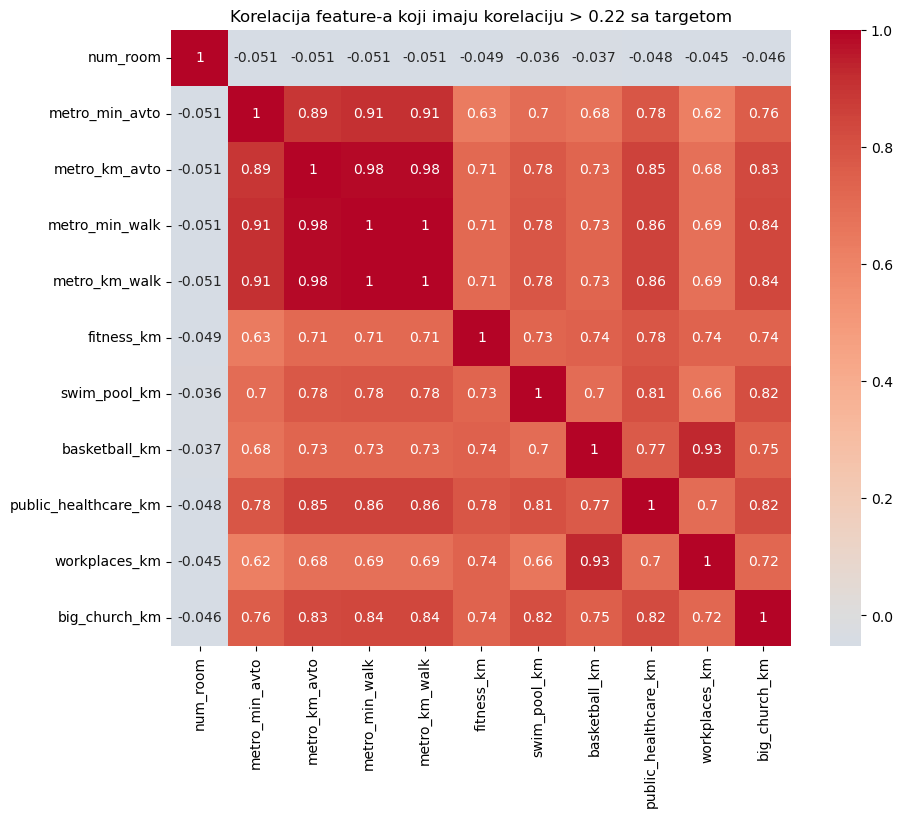

In [62]:
corr_treshold = 0.22

selected_features = columns_selector(train_num_with_target, corr_treshold = corr_treshold)
plt.figure(figsize=(10,8))
sns.heatmap(train_num_with_target[selected_features].corr(), annot=True, cmap="coolwarm", center=0)
plt.title(f"Korelacija feature-a koji imaju korelaciju > {corr_treshold} sa targetom")
plt.show()

In [63]:
def drop_hight_corr_pairs(train_num_with_target, selected_features, pairs_treshold=0.85):

    corr_matrix = train_num_with_target[selected_features].corr()
    
    df_cleared = train_num_with_target[selected_features]
    
    target_corr = df_cleared.corrwith(y_train).abs()
    
    high_corr_pairs = [
        (col1, col2)
        for col1 in corr_matrix.columns
        for col2 in corr_matrix.columns
        if col1 < col2 and corr_matrix.loc[col1, col2] > pairs_treshold
    ]
    
    print(high_corr_pairs)
    print(f"len: {len(high_corr_pairs)}")
    print()
    print("col1 to col2 ratio")
    print()
    cols_to_drop = []
    
    for c1, c2 in high_corr_pairs:
        if target_corr.get(c1, 0) < target_corr.get(c2, 0):
            print(f"{c1} < {c2}  :  {target_corr.get(c1, 0)} < {target_corr.get(c2, 0)}")
            cols_to_drop.append(c2)
        else:
            print(f"{c2} < {c1}  :  {target_corr.get(c2, 0)} < {target_corr.get(c1, 0)}")       
            cols_to_drop.append(c1)
    
    df_cleared = df_cleared.drop(columns=cols_to_drop)
    print()
    print("columns to keep :")
    print(df_cleared.columns)
    print(f"len: {len(df_cleared.columns)}")

    return df_cleared

In [64]:
df_cleared = drop_hight_corr_pairs(train_num_with_target, selected_features, pairs_treshold=0.9)
df_cleared.head()

[('metro_min_avto', 'metro_min_walk'), ('metro_km_avto', 'metro_min_walk'), ('metro_km_avto', 'metro_km_walk'), ('metro_km_walk', 'metro_min_avto'), ('metro_km_walk', 'metro_min_walk'), ('basketball_km', 'workplaces_km')]
len: 6

col1 to col2 ratio

metro_min_avto < metro_min_walk  :  0.2480851686919985 < 0.2627439168217937
metro_km_avto < metro_min_walk  :  0.26027498680977257 < 0.2627439168217937
metro_km_avto < metro_km_walk  :  0.26027498680977257 < 0.2627439168145528
metro_min_avto < metro_km_walk  :  0.2480851686919985 < 0.2627439168145528
metro_km_walk < metro_min_walk  :  0.2627439168145528 < 0.2627439168217937
basketball_km < workplaces_km  :  0.22142999874062969 < 0.22814390738516646

columns to keep :
Index(['num_room', 'metro_min_avto', 'metro_km_avto', 'fitness_km',
       'swim_pool_km', 'basketball_km', 'public_healthcare_km',
       'big_church_km'],
      dtype='object')
len: 8


,num_room,metro_min_avto,metro_km_avto,fitness_km,swim_pool_km,basketball_km,public_healthcare_km,big_church_km
6941,2.0,7.132375,6.541774,1.445152,6.818352,5.833935,6.032000,4.160115
12866,1.0,1.415677,1.132542,0.042363,2.080661,1.854369,1.087913,2.514386
604,2.0,2.821799,1.613995,0.733662,1.110417,1.762450,2.814092,0.507142
12523,1.0,4.607400,2.599410,0.749145,6.430725,2.107039,3.585709,1.866451
6467,2.0,2.783339,1.741787,0.305406,4.292076,1.560689,0.701909,3.065868


### 1. Dimenzije i sobe

full_sq → ukupna kvadratura stana (m²).

life_sq → stambena površina stana (m²), dakle samo sobe, bez hodnika, balkona i pomoćnih prostorija.

num_room → broj soba u stanu.

In [66]:
flags = []

In [67]:
def bar_plot(df, col, y_label="price_doc"):
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=40, color="steelblue", edgecolor="black")
    plt.title(f"Distribucija {col}")
    plt.xlabel(col)
    plt.ylabel(y_label)
    plt.show()

def scatter_plot(df, col, target = "price_doc"):
    plt.figure(figsize=(6,4))
    plt.scatter(df[col], df[target], alpha=0.3)
    plt.title(f"{col} vs {target}")
    plt.xlabel(col)
    plt.ylabel(target)
    plt.show()

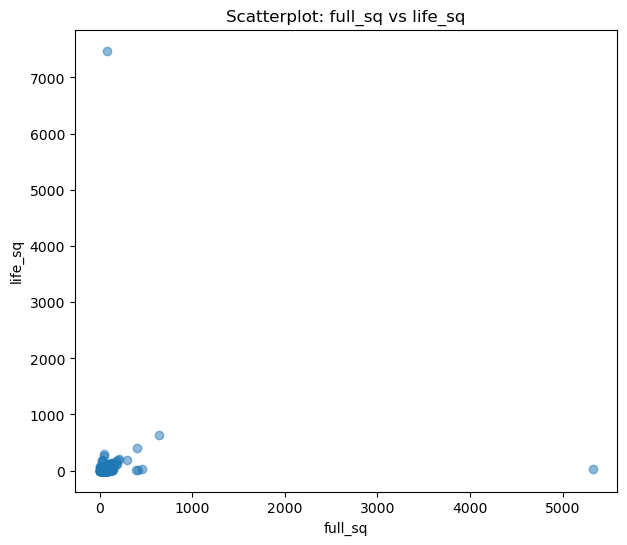

In [68]:
plt.figure(figsize=(7, 6))
plt.scatter(train_num_with_target["full_sq"], train_num_with_target["life_sq"], alpha=0.5)
plt.xlabel("full_sq")
plt.ylabel("life_sq")
plt.title("Scatterplot: full_sq vs life_sq")
plt.show()


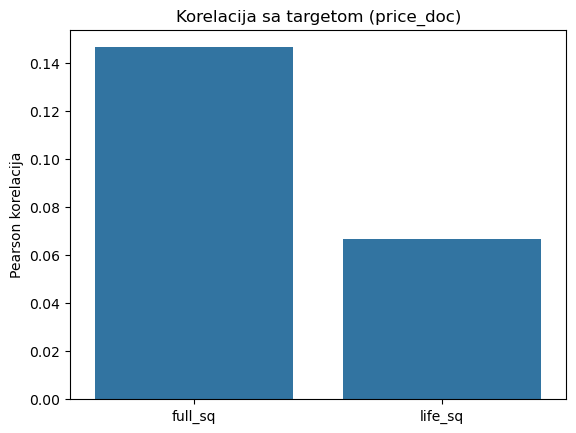

Korelacija full_sq sa targetom: 0.1464193112653408
Korelacija life_sq sa targetom: 0.0667381876503419


In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# Izračunaj korelaciju sa targetom
corr_full = train_num_with_target["full_sq"].corr(train_num_with_target["price_doc"])
corr_life = train_num_with_target["life_sq"].corr(train_num_with_target["price_doc"])

# Ubaci u dict pa u DataFrame za lakši plot
corr_dict = {
    "full_sq": corr_full,
    "life_sq": corr_life
}

sns.barplot(x=list(corr_dict.keys()), y=list(corr_dict.values()))
plt.title("Korelacija sa targetom (price_doc)")
plt.ylabel("Pearson korelacija")
plt.show()

print("Korelacija full_sq sa targetom:", corr_full)
print("Korelacija life_sq sa targetom:", corr_life)

* Solidna korelacija full_sq i life_sq sa targetom

* Loša međusobna korelacija

* Treba zadržati oba

In [71]:
bad_full = df[df["full_sq"] <= 0]
bad_life = df[df["life_sq"] <= 0]
bad_ratio = df[df["life_sq"] > df["full_sq"]]
bad_room_zero = df[df["num_room"] == 0]
bad_room_high = df[df["num_room"] > 10]
df["sqm_per_room"] = df["full_sq"] / df["num_room"].replace(0, np.nan)
bad_sqm_low = df[df["sqm_per_room"] < 8]
bad_sqm_high = df[df["sqm_per_room"] > 80]


print("Provera dal postoje stanovi sa kvadraturom < 0")
print("Kvadratura <= 0:", bad_full.shape[0])
print("life_sq <= 0:", bad_life.shape[0])
print("life_sq > full_sq:", bad_ratio.shape[0])
print("num_room = 0:", bad_room_zero.shape[0])
print("num_room > 10:", bad_room_high.shape[0])
print("sqm_per_room < 8:", bad_sqm_low.shape[0])
print("sqm_per_room > 80:", bad_sqm_high.shape[0])

Provera dal postoje stanovi sa kvadraturom < 0
Kvadratura <= 0: 2
life_sq <= 0: 43
life_sq > full_sq: 36
num_room = 0: 13
num_room > 10: 2
sqm_per_room < 8: 32
sqm_per_room > 80: 64


In [72]:
# --- life_sq ---
df["life_sq_missing_or_zero"] = (df["life_sq"] <= 0).astype(int)
df["life_sq_bigger_full"] = (df["life_sq"] > df["full_sq"]).astype(int)


df.loc[df["life_sq"] <= 0, "life_sq"] = np.nan
df.loc[df["life_sq"] > df["full_sq"], "life_sq"] = np.nan

# --- num_room ---
df["num_room_zero"] = (df["num_room"] == 0).astype(int)
df["num_room_outlier"] = (df["num_room"] > 10).astype(int)

df.loc[df["num_room"] == 0, "num_room"] = np.nan
df.loc[df["num_room"] > 10, "num_room"] = np.nan

df["sqm_per_room"] = df["full_sq"] / df["num_room"].replace(0, np.nan)

df["sqm_too_small"] = (df["sqm_per_room"] < 8).astype(int)
df["sqm_too_big"] = (df["sqm_per_room"] > 80).astype(int)

df.loc[df["sqm_per_room"] < 8, "num_room"] = np.nan
df.loc[df["sqm_per_room"] > 80, "num_room"] = np.nan


flags.extend(["life_sq_bigger_full","life_sq_bigger_full","num_room_zero","num_room_outlier","sqm_too_small","sqm_too_big"])
new_cols.extend(["sqm_per_room"])

Poredjenje full_sq sa num_room

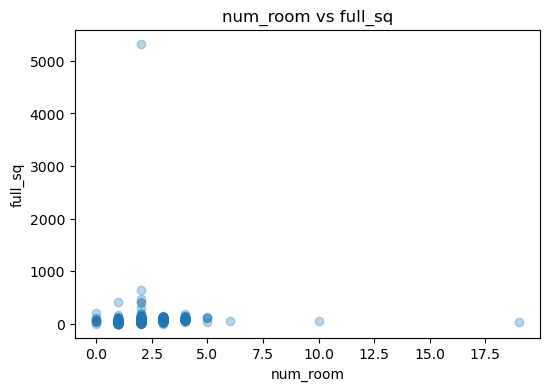

In [74]:
scatter_plot(train_num_with_target, col = "num_room",target="full_sq")

In [75]:
print("full_sq <= 0 :", df[df["full_sq"] <= 0].shape[0])
print("life_sq <= 0 :", df[df["life_sq"] <= 0].shape[0])

print("life_sq > full_sq :", df[df["life_sq"] > df["full_sq"]].shape[0])

print("num_room = 0 :", df[df["num_room"] == 0].shape[0])
print("num_room > 10 :", df[df["num_room"] > 10].shape[0])

print("sqm_per_room < 8 :", df[df["sqm_per_room"] < 8].shape[0])
print("sqm_per_room > 80 :", df[df["sqm_per_room"] > 80].shape[0])

full_sq <= 0 : 2
life_sq <= 0 : 0
life_sq > full_sq : 0
num_room = 0 : 0
num_room > 10 : 0
sqm_per_room < 8 : 30
sqm_per_room > 80 : 64


### 2. Saobraćaj i udaljenosti do centra

* metro_min_avto – vreme u minutima do najbliže metro stanice kolima

* kremlin_km – udaljenost u kilometrima do Kremlja

In [77]:
cols = ["metro_min_avto", "kremlin_km"]

print(df[cols].describe())

       metro_min_avto    kremlin_km
count    28906.000000  28906.000000
mean         3.761978     14.817453
std          3.871674      6.584910
min          0.000000      0.072897
25%          1.658981     10.182241
50%          2.667751     14.294238
75%          4.678993     20.362203
max         34.853238     29.986781


In [78]:
cols = ["metro_min_avto", "kremlin_km"]

thresholds = [0, 1, 2, 5, 10, 20, 50, 100]

for col in cols:
    print(f"\n=== {col} ===")
    for t in thresholds:
        count = (df[col] <= t).sum()
        print(f" <= {t}: {count}")



=== metro_min_avto ===
 <= 0: 1
 <= 1: 2278
 <= 2: 9627
 <= 5: 22994
 <= 10: 27803
 <= 20: 28689
 <= 50: 28906
 <= 100: 28906

=== kremlin_km ===
 <= 0: 0
 <= 1: 619
 <= 2: 700
 <= 5: 1973
 <= 10: 6992
 <= 20: 21330
 <= 50: 28906
 <= 100: 28906


In [79]:
mask = (df["metro_min_avto"] < 0.5) | (df["kremlin_km"] < 0.1)
df.loc[mask, ["metro_min_avto", "kremlin_km"]] = np.nan
df["is_near_kremlin"] = (df["kremlin_km"] < 1).astype(int)
flags.extend(["is_near_kremlin"])

In [80]:
df.loc[mask, ["metro_min_avto", "kremlin_km"]]

,metro_min_avto,kremlin_km
23,NaN,NaN
74,NaN,NaN
157,NaN,NaN
199,NaN,NaN
313,NaN,NaN
...,...,...
30320,NaN,NaN
30354,NaN,NaN
30377,NaN,NaN
30441,NaN,NaN


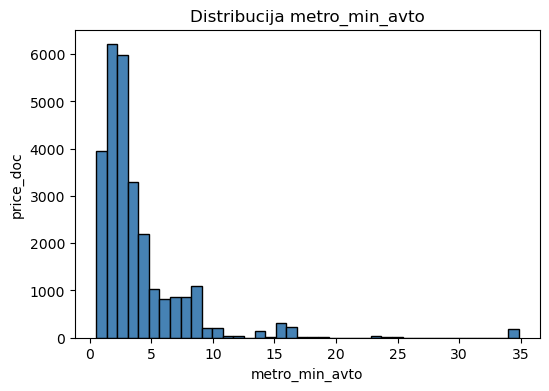

In [81]:
bar_plot(df, col = "metro_min_avto")

In [82]:
df["metro_far"] = (df["metro_min_avto"] > 30).astype(int)
df.loc[df["metro_min_avto"] > 30, "metro_min_avto"] = np.nan
flags.extend(["metro_far"])

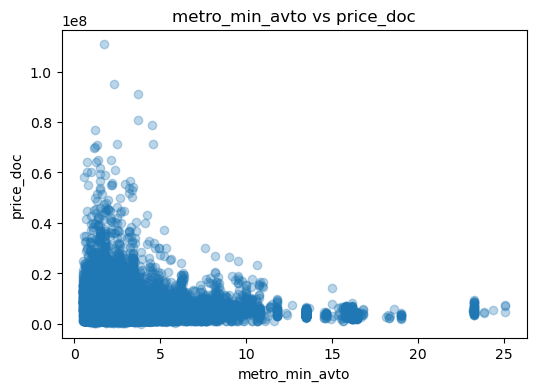

In [83]:
scatter_plot(df, col = "metro_min_avto")

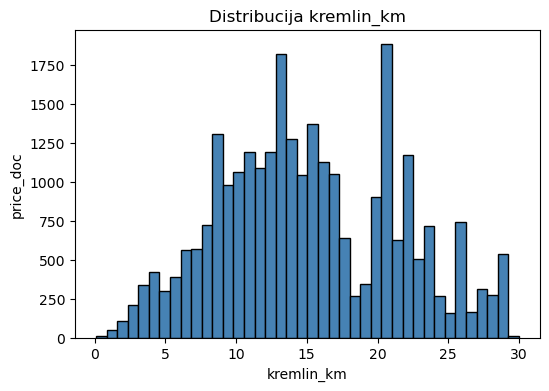

In [84]:
bar_plot(df, col = "kremlin_km")

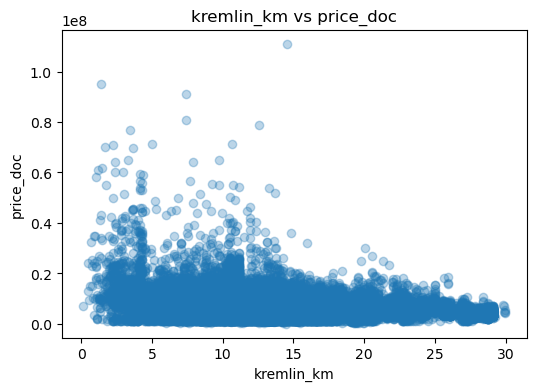

In [85]:
scatter_plot(df, col = "kremlin_km")

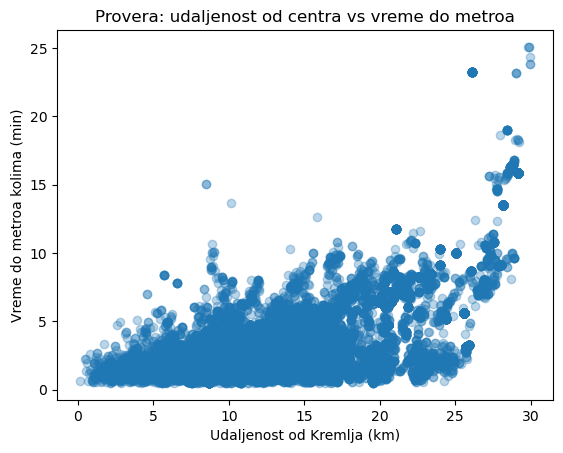

In [86]:
plt.scatter(df["kremlin_km"], df["metro_min_avto"], alpha=0.3)
plt.xlabel("Udaljenost od Kremlja (km)")
plt.ylabel("Vreme do metroa kolima (min)")
plt.title("Provera: udaljenost od centra vs vreme do metroa")
plt.show()

### 3. Okruženje i infrastruktura

* workplaces_km – udaljenost u kilometrima do poslovnih centara

* catering_km – udaljenost u kilometrima do najbližeg restorana ili ketering objekta

* big_church_km – udaljenost u kilometrima do najbliže velike crkve

In [88]:
cols = ["workplaces_km", "catering_km", "big_church_km"]

# pragovi za "previše daleko"
thresholds = {
    "workplaces_km": 50,   # poslovni centri su uglavnom u centru
    "catering_km": 20,     # restorani teško da su preko 20 km daleko
    "big_church_km": 30    # velike crkve obično u gradu
}

for col in cols:
    print(f"\n=== {col} ===")
    print(f"Ukupno vrednosti: {df[col].shape[0]}")
    print(f"=0: {(df[col] == 0).sum()}")
    print(f"> {thresholds[col]} km: {(df[col] > thresholds[col]).sum()}")
    print(f"Min: {df[col].min()}, Max: {df[col].max()}")
    print()

# dodatne neusaglašenosti sa kremlin_km
print("\n=== Neusaglašenosti u odnosu na kremlin_km ===")
print("workplaces dalje od 2x kremlin:", (df["workplaces_km"] > 2 * df["kremlin_km"]).sum())
print("catering dalje od 10 km i kremlin < 5 km:", ((df["catering_km"] > 10) & (df["kremlin_km"] < 5)).sum())
print("big_church dalje od 20 km i kremlin < 5 km:", ((df["big_church_km"] > 20) & (df["kremlin_km"] < 5)).sum())



=== workplaces_km ===
Ukupno vrednosti: 28906
=0: 13
> 50 km: 0
Min: 0.0, Max: 14.50964427


=== catering_km ===
Ukupno vrednosti: 28906
=0: 0
> 20 km: 0
Min: 0.000356696, Max: 4.117323591


=== big_church_km ===
Ukupno vrednosti: 28906
=0: 0
> 30 km: 0
Min: 0.004071872, Max: 10.35646043


=== Neusaglašenosti u odnosu na kremlin_km ===
workplaces dalje od 2x kremlin: 5
catering dalje od 10 km i kremlin < 5 km: 0
big_church dalje od 20 km i kremlin < 5 km: 0


In [89]:
df["workplaces_zero"] = (df["workplaces_km"] == 0).astype(int)
df["workplaces_far"] = (df["workplaces_km"] > 50).astype(int)
df["big_church_far"] = (df["big_church_km"] > 30).astype(int)

df.loc[df["workplaces_km"] == 0, "workplaces_km"] = np.nan
df.loc[df["workplaces_km"] > 50, "workplaces_km"] = np.nan
df.loc[df["big_church_km"] > 30, "big_church_km"] = np.nan

flags.extend(["workplaces_zero","workplaces_far","big_church_far"])

### 4. Posebne lokacije

* nuclear_reactor_km – udaljenost do nuklearnog reaktora

* detention_facility_km – udaljenost do zatvora / pritvorske jedinice


In [91]:
cols = {
    "nuclear_reactor_km": 100,       # prag za ekstremno daleko
    "detention_facility_km": 60      # prag za ekstremno daleko
}

for col, thr in cols.items():
    print(f"\n=== {col} ===")
    print(f"Ukupno vrednosti: {df[col].shape[0]}")
    print(f"=0: {(df[col] == 0).sum()}")
    print(f"<0.1 km: {(df[col] < 0.1).sum()}")   # praktično "u objektu"
    print(f"> {thr} km: {(df[col] > thr).sum()}")
    print(f"Min: {df[col].min()}, Max: {df[col].max()}")



=== nuclear_reactor_km ===
Ukupno vrednosti: 28906
=0: 0
<0.1 km: 0
> 100 km: 0
Min: 0.309810795, Max: 23.97081657

=== detention_facility_km ===
Ukupno vrednosti: 28906
=0: 0
<0.1 km: 2
> 60 km: 0
Min: 0.041227084, Max: 41.33222411


In [92]:
df["detention_far"] = (df["detention_facility_km"] > 60).astype(int)
df.loc[df["detention_facility_km"] > 60, "detention_facility_km"] = np.nan
flags.extend(["detention_far"])

In [93]:
df["price_per_m2"] = df["price_doc"] / df["full_sq"]
df = df[df["price_per_m2"].notnull() & (df["price_per_m2"] < 1_000_000)].copy() # ukloni outliere

# Log transformacija
df["log_price_per_m2"] = np.log(df["price_per_m2"])

In [94]:
print(df.shape)

(28878, 310)


In [95]:
df_num = df.select_dtypes("number")

Feature-i sa korelacijom > 0.25 sa targetom:
['full_sq', 'life_sq', 'num_room', 'ttk_km', 'sadovoe_km', 'bulvar_ring_km', 'kremlin_km', 'zd_vokzaly_avto_km', 'nuclear_reactor_km', 'sport_count_2000', 'sport_count_3000', 'office_sqm_5000', 'trc_count_5000', 'trc_sqm_5000', 'sport_count_5000', 'price_doc_log', 'price_per_m2', 'log_price_per_m2']


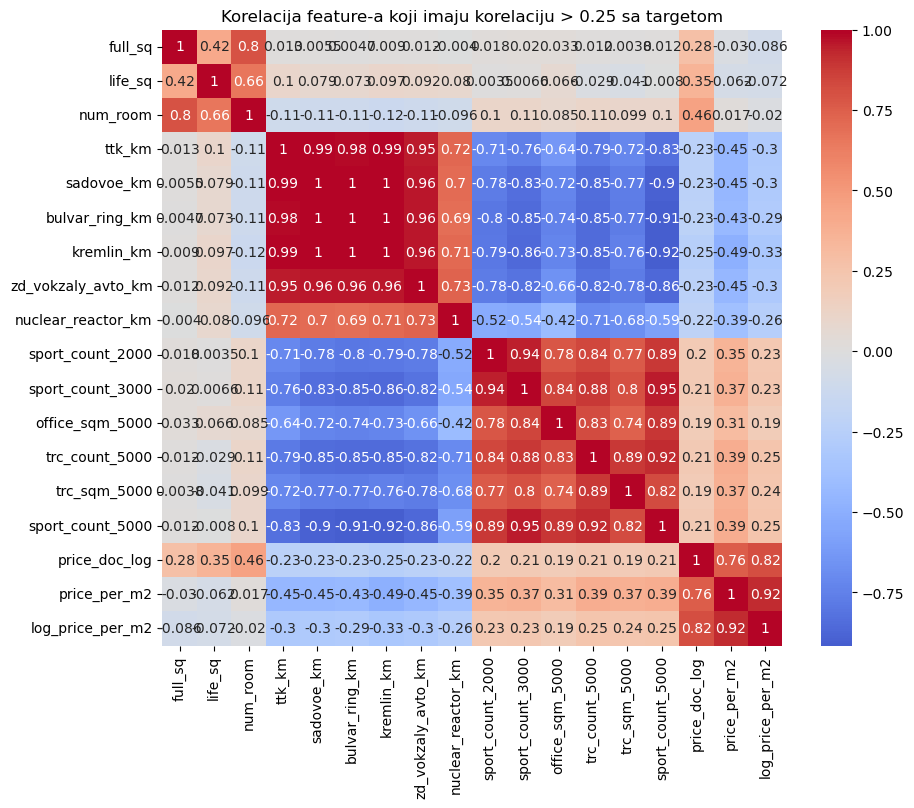

In [215]:
corr_treshold = 0.25
selected_features = columns_selector(df_num, corr_treshold = corr_treshold)
plt.figure(figsize=(10,8))
sns.heatmap(df_num[selected_features].corr(), annot=True, cmap="coolwarm", center=0)
plt.title(f"Korelacija feature-a koji imaju korelaciju > {corr_treshold} sa targetom")
plt.show()

In [97]:
print(flags)

['life_sq_bigger_full', 'life_sq_bigger_full', 'num_room_zero', 'num_room_outlier', 'sqm_too_small', 'sqm_too_big', 'is_near_kremlin', 'metro_far', 'workplaces_zero', 'workplaces_far', 'big_church_far', 'detention_far']


In [98]:
print(new_cols)

['year', 'month', 'floor_ratio', 'build_age', 'sqm_per_room']


In [99]:
df_cleared = drop_hight_corr_pairs(df_num, selected_features, pairs_treshold=0.9)

[('metro_km_avto', 'metro_min_walk'), ('metro_km_avto', 'metro_km_walk'), ('metro_km_walk', 'metro_min_walk'), ('ttk_km', 'zd_vokzaly_avto_km'), ('sadovoe_km', 'ttk_km'), ('sadovoe_km', 'zd_vokzaly_avto_km'), ('bulvar_ring_km', 'ttk_km'), ('bulvar_ring_km', 'sadovoe_km'), ('bulvar_ring_km', 'kremlin_km'), ('bulvar_ring_km', 'zd_vokzaly_avto_km'), ('kremlin_km', 'ttk_km'), ('kremlin_km', 'sadovoe_km'), ('kremlin_km', 'zd_vokzaly_avto_km'), ('basketball_km', 'workplaces_km'), ('sport_count_1500', 'sport_count_2000'), ('sport_count_2000', 'sport_count_3000'), ('office_sqm_3000', 'office_sqm_5000'), ('trc_count_3000', 'trc_count_5000'), ('sport_count_3000', 'sport_count_5000'), ('cafe_count_5000', 'office_sqm_3000'), ('cafe_count_5000', 'office_sqm_5000'), ('cafe_count_5000', 'cafe_count_5000_na_price'), ('cafe_count_5000', 'cafe_count_5000_price_500'), ('cafe_count_5000', 'cafe_count_5000_price_1000'), ('cafe_count_5000', 'cafe_count_5000_price_1500'), ('cafe_count_5000', 'cafe_count_5000

In [100]:
hight_corr_cols = ['full_sq', 'life_sq', 'num_room', 'sport_objects_raion',
       'metro_min_walk', 'zd_vokzaly_avto_km', 'nuclear_reactor_km',
       'thermal_power_plant_km', 'swim_pool_km', 'stadium_km',
       'public_healthcare_km', 'university_km', 'workplaces_km', 'office_km',
       'big_church_km', 'theater_km', 'exhibition_km', 'catering_km',
       'sport_count_1500', 'office_sqm_2000', 'trc_count_3000', 'trc_sqm_3000',
       'trc_sqm_5000', 'big_church_count_5000']

df_cat = df.select_dtypes("object")
cat_cols = df_cat.columns

In [101]:
def merge_cols(*lists):
    seen = set()
    merged = []
    for lst in lists:
        for col in lst:
            if col not in seen:
                merged.append(col)
                seen.add(col)
    return merged

In [102]:
flags

['life_sq_bigger_full',
 'life_sq_bigger_full',
 'num_room_zero',
 'num_room_outlier',
 'sqm_too_small',
 'sqm_too_big',
 'is_near_kremlin',
 'metro_far',
 'workplaces_zero',
 'workplaces_far',
 'big_church_far',
 'detention_far']

In [305]:
df_hight_corr = df[merge_cols(hight_corr_cols,["price_doc_log","price_doc"])]
df_full = df

df_hybrid1 = df[merge_cols(hight_corr_cols, flags,["price_doc_log","price_doc"])]
df_hybrid2 = df[merge_cols(hight_corr_cols, flags, new_cols,["price_doc_log","price_doc"])]
df_hybrid3 = df[merge_cols(hight_corr_cols, flags, new_cols, cat_cols,["price_doc_log","price_doc"])]

In [104]:
df_hight_corr.dtypes.value_counts()

float64    17
int64       9
Name: count, dtype: int64

In [105]:
df_hybrid1.dtypes.value_counts()

float64    17
int32      11
int64       9
Name: count, dtype: int64

In [106]:
df_hybrid2.dtypes.value_counts()

float64    20
int32      13
int64       9
Name: count, dtype: int64

In [107]:
df_hybrid3.dtypes.value_counts()

float64    20
object     15
int32      13
int64       9
Name: count, dtype: int64

In [108]:
ordinal_cols = ["ecology"] 
freq_cols = ["sub_area"]
nominal_cols = [col for col in cat_cols if col not in ordinal_cols + freq_cols]
print(nominal_cols)
order = [["excellent", "good", "satisfactory", "poor"]]

['product_type', 'culture_objects_top_25', 'thermal_power_plant_raion', 'incineration_raion', 'oil_chemistry_raion', 'radiation_raion', 'railroad_terminal_raion', 'big_market_raion', 'nuclear_reactor_raion', 'detention_facility_raion', 'water_1line', 'big_road1_1line', 'railroad_1line']


In [109]:
df_hybrid3.loc[:, "ecology"] = df_hybrid3["ecology"].replace("no data", np.nan)
df.loc[:, "ecology"] = df["ecology"].replace("no data", np.nan)

In [110]:
class FrequencyEncoder2(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None, normalize=True):
        self.columns = columns
        self.normalize = normalize
        self.freq_maps = {}

    def fit(self, X, y=None):
        # Ako nije DataFrame, napravi ga
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.columns)

        for col in self.columns:
            self.freq_maps[col] = X[col].value_counts(normalize=self.normalize)
        return self

    def transform(self, X):
        # Ako nije DataFrame, napravi ga
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.columns)

        X = X.copy()
        for col in self.columns:
            X[col] = X[col].map(self.freq_maps[col]).fillna(0)
        return X
    def get_feature_names_out(self, input_features=None):
        return np.array(self.columns)

In [111]:
hybrid1_cols = list(dict.fromkeys(hight_corr_cols + flags))
hybrid2_cols = list(dict.fromkeys(hight_corr_cols + flags + new_cols))

In [112]:
dupes = [col for col, cnt in Counter(hybrid1_cols).items() if cnt > 1]
print("Duplikati:", dupes)

Duplikati: []


In [113]:
def create_preprocessor(nominal_cols, ordinal_cols, freq_cols, numeric_cols):
    preprocessor = ColumnTransformer(
        transformers=[
            ("nominal", 
             Pipeline([
                 ("imputer", SimpleImputer(strategy="most_frequent")),
                 ("ohe", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False))
             ]), 
             nominal_cols),
            ("ordinal", 
             Pipeline([
                 ("imputer", SimpleImputer(strategy="most_frequent")),
                 ("ord", OrdinalEncoder(categories=[["excellent", "good", "satisfactory", "poor"]]))
             ]), 
             ordinal_cols),
            ("freq", 
             Pipeline([
                 ("imputer", SimpleImputer(strategy="most_frequent")),
                 ("freq", FrequencyEncoder2(columns=freq_cols))
             ]), 
             freq_cols),
            ("num", 
             Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median"))
            ]),
             numeric_cols)
        ],
        remainder="drop"
    )

    pipeline = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("quantile", QuantileTransformer(output_distribution="normal", random_state=42))
    ])
    return pipeline

In [114]:
def create_numeric_preprocessor(cols):

    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("quantile", QuantileTransformer(output_distribution="normal", random_state=42))
    ])
    
    num_preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, cols)
    ])
    return num_preprocessor

In [251]:
def return_train_test(df_):
    # koristi globalni df za target
    y = df_["price_doc_log"]
  
    
    X = df_.drop(columns=["price_doc","price_doc_log"])  # sve kolone u df_
    return train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


In [116]:
def evaluate_regression(y_true, y_pred):
    # ako ima negativnih predikcija → postavi na 0 zbog RMSLE
    y_pred_clip = np.maximum(0, y_pred)

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmsle = np.sqrt(mean_squared_log_error(y_true, y_pred_clip))

    print("MSE: ", mse)
    print("RMSE: ", rmse)
    print("MAE: ", mae)
    print("R²: ", r2)
    print("RMSLE: ", rmsle)

    results = {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R²": r2,
        "RMSLE": rmsle
    }
    return results

In [117]:

X_train, X_test, y_train, y_test = return_train_test(df_hight_corr)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (23102, 25)
X_test shape: (5776, 25)
y_train shape: (23102,)
y_test shape: (5776,)


In [118]:
def unlog(y_log_pred):
    return np.expm1(y_log_pred)


In [146]:
X_train, X_test, y_train, y_test = return_train_test(df_hight_corr)

num_cols = df_hight_corr.drop(columns = ["price_doc_log","price_doc"]).columns

numeric_preprocessor = create_numeric_preprocessor(num_cols)
pipeline = Pipeline(steps=[
    ("preprocessor", numeric_preprocessor),
    ("model", LinearRegression())
])

pipeline.fit(X_train, y_train)
print("Broj kolona nakon preprocesiranja:", pipeline.named_steps["preprocessor"].transform(X_train).shape[1])


y_pred = pipeline.predict(X_test)
y_pred = unlog(y_pred)
y_test = unlog(y_test)

evaluate_regression(y_test, y_pred)

Broj kolona nakon preprocesiranja: 24
MSE:  11293369546057.807
RMSE:  3360560.8975374643
MAE:  1954808.9724598548
R²:  0.47740245130619907
RMSLE:  0.48003854141976376


{'MSE': 11293369546057.807,
 'RMSE': 3360560.8975374643,
 'MAE': 1954808.9724598548,
 'R²': 0.47740245130619907,
 'RMSLE': 0.48003854141976376}

In [197]:


X_train, X_test, y_train, y_test = return_train_test(df_hybrid1)

num_cols = df_hybrid1.drop(columns = ["price_doc_log","price_doc"]).columns

numeric_preprocessor_hybrid1 = create_numeric_preprocessor(num_cols)


pipeline = Pipeline(steps=[
    ("preprocessor", numeric_preprocessor_hybrid1),
    ("model", LinearRegression())
])

pipeline.fit(X_train, y_train)
print("Broj kolona nakon preprocesiranja:", pipeline.named_steps["preprocessor"].transform(X_train).shape[1])


y_pred = pipeline.predict(X_test)
y_pred = unlog(y_pred)
y_test = unlog(y_test)

evaluate_regression(y_test, y_pred)

Broj kolona nakon preprocesiranja: 35
MSE:  11209872857362.695
RMSE:  3348114.8214125955
MAE:  1948617.5026553385
R²:  0.4812662374559533
RMSLE:  0.4790796394593019


{'MSE': 11209872857362.695,
 'RMSE': 3348114.8214125955,
 'MAE': 1948617.5026553385,
 'R²': 0.4812662374559533,
 'RMSLE': 0.4790796394593019}

In [217]:
X_train, X_test, y_train, y_test = return_train_test(df_hybrid2)

num_cols = df_hybrid2.drop(columns = ["price_doc_log","price_doc"]).columns

numeric_preprocessor_hybrid2 = create_numeric_preprocessor(num_cols)

pipeline = Pipeline(steps=[
    ("preprocessor", numeric_preprocessor_hybrid2),
    ("model", LinearRegression())
])

pipeline.fit(X_train, y_train)
print("Broj kolona nakon preprocesiranja:", pipeline.named_steps["preprocessor"].transform(X_train).shape[1])


y_pred = pipeline.predict(X_test)
y_pred = unlog(y_pred)
y_unlog = unlog(y_test)

evaluate_regression(y_unlog, y_pred)

Broj kolona nakon preprocesiranja: 40
MSE:  10684061741995.5
RMSE:  3268648.3050330607
MAE:  1910184.3771520369
R²:  0.5055980012263835
RMSLE:  0.47426471536730386


{'MSE': 10684061741995.5,
 'RMSE': 3268648.3050330607,
 'MAE': 1910184.3771520369,
 'R²': 0.5055980012263835,
 'RMSLE': 0.47426471536730386}

In [201]:
# isti train/test kao i za linearni model
X_train, X_test, y_train, y_test = return_train_test(df_hybrid2)
num_cols = df_hybrid2.drop(columns = ["price_doc_log","price_doc"]).columns
numeric_preprocessor_hybrid2 = create_numeric_preprocessor(num_cols)
# pipeline sa Ridge umesto LinearRegression
for alpha in [0.1, 1, 10, 100, 1000]:
    ridge_pipeline = Pipeline(steps=[
        ("preprocessor", numeric_preprocessor_hybrid2),
        ("model", Ridge(alpha=alpha, random_state=42))
    ])

    ridge_pipeline.fit(X_train, y_train)
    y_pred = ridge_pipeline.predict(X_test)

    y_pred = unlog(y_pred)
    y_test_unlog = unlog(y_test)

    print(f"\n=== Ridge alpha={alpha} ===")
    evaluate_regression(y_test_unlog, y_pred)



=== Ridge alpha=0.1 ===
MSE:  10684091544019.775
RMSE:  3268652.863798751
MAE:  1910185.6831136881
R²:  0.5055966221459621
RMSLE:  0.4742647075199992

=== Ridge alpha=1 ===
MSE:  10684359759200.646
RMSE:  3268693.891939202
MAE:  1910197.4346836412
R²:  0.5055842105627342
RMSLE:  0.4742646374381116

=== Ridge alpha=10 ===
MSE:  10687041613172.34
RMSE:  3269104.0994701195
MAE:  1910314.8712408023
R²:  0.5054601085127794
RMSLE:  0.4742639902361156

=== Ridge alpha=100 ===
MSE:  10713831960303.459
RMSE:  3273199.0407403363
MAE:  1911492.5374424686
R²:  0.5042203926173348
RMSLE:  0.4742626660002935

=== Ridge alpha=1000 ===
MSE:  10976992324052.564
RMSE:  3313154.437096551
MAE:  1924918.6984389469
R²:  0.4920427196519921
RMSLE:  0.4746092101131993


In [229]:
numeric_preprocessor_hybrid2 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# pipeline sa Ridge
ridge_pipeline_scaled = Pipeline(steps=[
    ("preprocessor", numeric_preprocessor_hybrid2),
    ("model", Ridge(alpha=0.1, random_state=42))  # start sa najboljim alpha
])

# treniranje
X_train, X_test, y_train, y_test = return_train_test(df_hybrid2)
ridge_pipeline_scaled.fit(X_train, y_train)

print("Broj kolona nakon preprocesiranja:", 
      ridge_pipeline_scaled.named_steps["preprocessor"].transform(X_train).shape[1])

# predikcije
y_pred = ridge_pipeline_scaled.predict(X_test)
y_pred = unlog(y_pred)
y_test_unlog = unlog(y_test)

# evaluacija
print(evaluate_regression(y_test_unlog, y_pred))

Broj kolona nakon preprocesiranja: 41
MSE:  750.9171829911157
RMSE:  27.40286815264263
MAE:  13.436069071982129
R²:  0.9999999999652515
RMSLE:  3.0290258161158163e-06
{'MSE': 750.9171829911157, 'RMSE': 27.40286815264263, 'MAE': 13.436069071982129, 'R²': 0.9999999999652515, 'RMSLE': 3.0290258161158163e-06}


In [255]:
from sklearn.linear_model import Lasso

# pipeline sa Lasso regresijom

X_train, X_test, y_train, y_test = return_train_test(df_hybrid2)

for alpha in [0.0001, 0.001, 0.01, 0.1, 1]:
    lasso_pipeline = Pipeline(steps=[
        ("preprocessor", numeric_preprocessor_hybrid2),
        ("model", Lasso(alpha=0.001, random_state=42, max_iter=10000))
    ])
    
    # treniranje
    lasso_pipeline.fit(X_train, y_train)
    
    print("Broj kolona nakon preprocesiranja:", 
          lasso_pipeline.named_steps["preprocessor"].transform(X_train).shape[1])
    
    # predikcije
    y_pred = lasso_pipeline.predict(X_test)
    y_pred = unlog(y_pred)
    y_test_unlog = unlog(y_test)
    
    # evaluacija
    print(alpha)
    print()
    print(evaluate_regression(y_test_unlog, y_pred))


Broj kolona nakon preprocesiranja: 40
0.0001

MSE:  1.7908599952493182e+16
RMSE:  133823017.27465713
MAE:  3832682.4453254966
R²:  -827.7155040435043
RMSLE:  0.49983053591938814
{'MSE': 1.7908599952493182e+16, 'RMSE': 133823017.27465713, 'MAE': 3832682.4453254966, 'R²': -827.7155040435043, 'RMSLE': 0.49983053591938814}
Broj kolona nakon preprocesiranja: 40
0.001

MSE:  1.7908599952493182e+16
RMSE:  133823017.27465713
MAE:  3832682.4453254966
R²:  -827.7155040435043
RMSLE:  0.49983053591938814
{'MSE': 1.7908599952493182e+16, 'RMSE': 133823017.27465713, 'MAE': 3832682.4453254966, 'R²': -827.7155040435043, 'RMSLE': 0.49983053591938814}
Broj kolona nakon preprocesiranja: 40
0.01

MSE:  1.7908599952493182e+16
RMSE:  133823017.27465713
MAE:  3832682.4453254966
R²:  -827.7155040435043
RMSLE:  0.49983053591938814
{'MSE': 1.7908599952493182e+16, 'RMSE': 133823017.27465713, 'MAE': 3832682.4453254966, 'R²': -827.7155040435043, 'RMSLE': 0.49983053591938814}
Broj kolona nakon preprocesiranja: 40
0.

In [257]:
for alpha in [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 500, 1000]:
    lasso = Lasso(alpha=alpha, random_state=42, max_iter=10000)
    model = Pipeline(steps=[
        ("preprocessor", numeric_preprocessor_hybrid2),
        ("model", lasso)
    ])
    model.fit(X_train, y_train)
    
    coef = model.named_steps["model"].coef_
    nonzero = np.sum(coef != 0)
    
    print(f"alpha={alpha} → broj aktivnih feature-a: {nonzero}")

alpha=0.0001 → broj aktivnih feature-a: 36
alpha=0.001 → broj aktivnih feature-a: 32
alpha=0.01 → broj aktivnih feature-a: 16
alpha=0.1 → broj aktivnih feature-a: 5
alpha=1 → broj aktivnih feature-a: 0
alpha=10 → broj aktivnih feature-a: 0
alpha=100 → broj aktivnih feature-a: 0
alpha=500 → broj aktivnih feature-a: 0
alpha=1000 → broj aktivnih feature-a: 0


In [259]:

results = {}

#kombinacije alpha i l1_ratio
for alpha in [0.0001, 0.001, 0.01, 0.1, 1, 10]:
    for l1_ratio in [0.2, 0.5, 0.7, 0.9]:
        model = Pipeline(steps=[
            ("preprocessor", numeric_preprocessor_hybrid2),
            ("model", ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42, max_iter=10000))
        ])
        
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        y_pred = unlog(y_pred)
        y_test_unlog = unlog(y_test)

        metrics = evaluate_regression(y_test_unlog, y_pred)
        
        results[(alpha, l1_ratio)] = metrics
        print(f"alpha={alpha}, l1_ratio={l1_ratio} → {metrics}")


MSE:  1.929898590222297e+16
RMSE:  138920790.0287893
MAE:  3896109.2727565896
R²:  -892.0552288797228
RMSLE:  0.49968836257532007
alpha=0.0001, l1_ratio=0.2 → {'MSE': 1.929898590222297e+16, 'RMSE': 138920790.0287893, 'MAE': 3896109.2727565896, 'R²': -892.0552288797228, 'RMSLE': 0.49968836257532007}
MSE:  1.9266374714139684e+16
RMSE:  138803367.08502313
MAE:  3894639.0175561137
R²:  -890.5461551809642
RMSLE:  0.4996888164242088
alpha=0.0001, l1_ratio=0.5 → {'MSE': 1.9266374714139684e+16, 'RMSE': 138803367.08502313, 'MAE': 3894639.0175561137, 'R²': -890.5461551809642, 'RMSLE': 0.4996888164242088}
MSE:  1.924448552335064e+16
RMSE:  138724495.03728834
MAE:  3893650.894357306
R²:  -889.5332389381554
RMSLE:  0.4996891654020637
alpha=0.0001, l1_ratio=0.7 → {'MSE': 1.924448552335064e+16, 'RMSE': 138724495.03728834, 'MAE': 3893650.894357306, 'R²': -889.5332389381554, 'RMSLE': 0.4996891654020637}
MSE:  1.9222535720331212e+16
RMSE:  138645359.53406882
MAE:  3892660.676327483
R²:  -888.51751788116

In [261]:
def rmsle(y_true, y_pred):
    # osiguraj da nema negativnih vrednosti
    y_true = np.maximum(0, y_true)
    y_pred = np.maximum(0, y_pred)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

In [263]:


# Pipeline: preprocesiranje + ElasticNet
pipe = Pipeline(steps=[
    ("preprocessor", numeric_preprocessor_hybrid2),
    ("model", ElasticNet(random_state=42, max_iter=10000))
])

rmsle_scorer = make_scorer(rmsle, greater_is_better=False)

# param grid
param_grid = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10],
    "model__l1_ratio": [0.2, 0.5, 0.7, 0.9]
}

# GridSearchCV
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,                # 5-fold cross validation
    scoring=rmsle_scorer,  # možeš i "r2" ili custom RMSLE
    n_jobs=-1            # koristi sve procesore
)

# fit
grid.fit(X_train, y_train)

print("Najbolji parametri:", grid.best_params_)
print("Najbolji score (RMSLE):", grid.best_score_)

best_model = grid.best_estimator_

# predikcija na test setu
y_pred = best_model.predict(X_test)

# vrati iz loga (ako je target bio logovan)
y_pred = unlog(y_pred)
y_test_unlog = unlog(y_test)

# izračunaj metrike
metrics = evaluate_regression(y_test_unlog, y_pred)

print("Test set performance sa najboljim parametrima:")
for k, v in metrics.items():
    print(f"{k}: {v}")

Najbolji parametri: {'model__alpha': 0.01, 'model__l1_ratio': 0.5}
Najbolji score (RMSLE): -0.03265783190483927
MSE:  1.0854241768071322e+16
RMSE:  104183692.42866814
MAE:  3466910.745619303
R²:  -501.2770323586917
RMSLE:  0.5014408786897026
Test set performance sa najboljim parametrima:
MSE: 1.0854241768071322e+16
RMSE: 104183692.42866814
MAE: 3466910.745619303
R²: -501.2770323586917
RMSLE: 0.5014408786897026


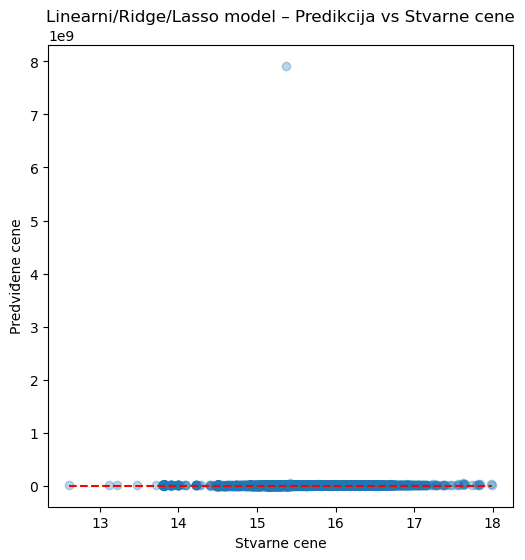

In [265]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")  # idealna linija
plt.xlabel("Stvarne cene")
plt.ylabel("Predviđene cene")
plt.title("Linearni/Ridge/Lasso model – Predikcija vs Stvarne cene")
plt.show()

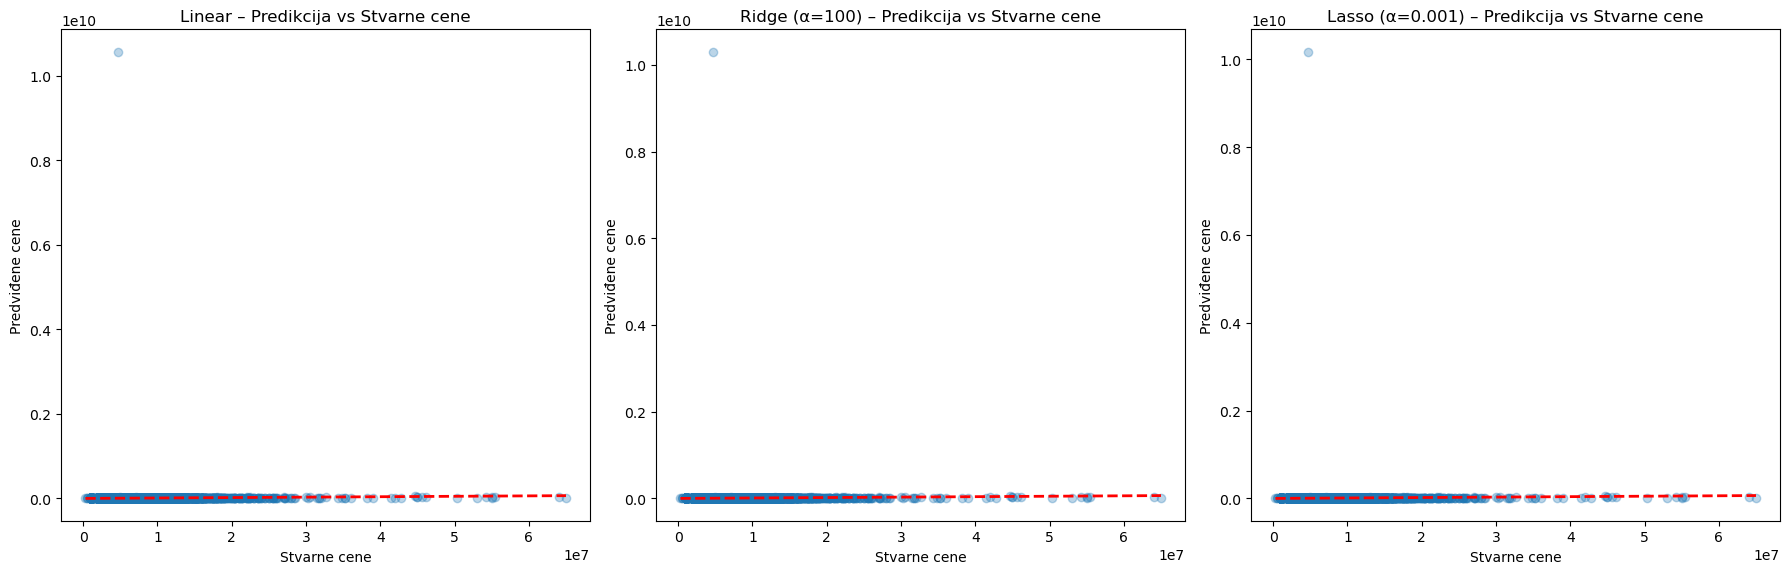

In [267]:
models = {
    "Linear": LinearRegression(),
    "Ridge (α=100)": Ridge(alpha=100, random_state=42),
    "Lasso (α=0.001)": Lasso(alpha=0.001, random_state=42, max_iter=10000)
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, model) in zip(axes, models.items()):
    pipeline = Pipeline(steps=[
        ("preprocessor", numeric_preprocessor_hybrid2),
        ("model", model)
    ])
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_pred = unlog(y_pred)
    y_true = unlog(y_test)

    # scatter
    ax.scatter(y_true, y_pred, alpha=0.3)
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()],
            "r--", lw=2)
    ax.set_title(f"{name} – Predikcija vs Stvarne cene")
    ax.set_xlabel("Stvarne cene")
    ax.set_ylabel("Predviđene cene")

plt.tight_layout()
plt.show()


R² je negativan – jer model u proseku promašuje gore nego što bi prosek pogodio.

RMSLE izgleda bolje – jer RMSLE ublažava uticaj outliera (log transformacija).

Graf pokazuje da model radi za većinu tipičnih primera, ali outlieri ga razbijaju.

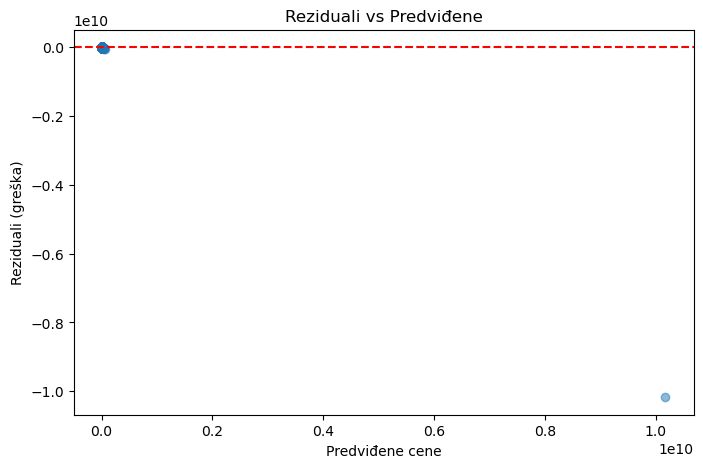

In [269]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color="r", linestyle="--")
plt.xlabel("Predviđene cene")
plt.ylabel("Reziduali (greška)")
plt.title("Reziduali vs Predviđene")
plt.show()


Reziduali vs Predviđene

Idealno: tačke treba da budu nasumično raspoređene oko crvene linije (0).

Kod tebe: vidimo jak bias i outliere → model sistematski promašuje i podcenjuje ili precenjuje cene. To je znak da linearni model nije dovoljno fleksibilan.

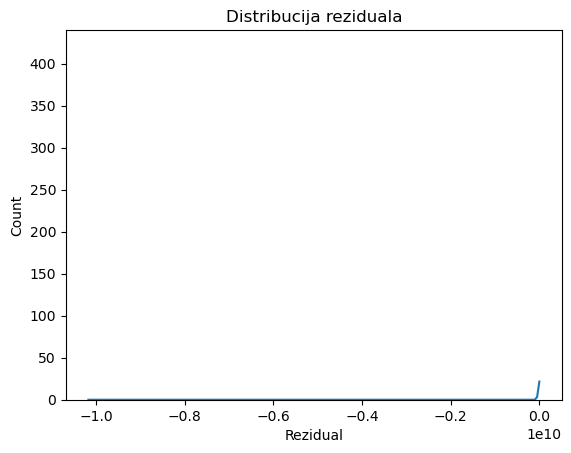

In [273]:
sns.histplot(residuals, kde=True)
plt.xlabel("Rezidual")
plt.title("Distribucija reziduala")
plt.show()


Idealno: simetrična i zvonasta (oko 0).

Kod tebe: jako leva asimetrija (dosta negativnih grešaka). To znači da ima puno slučajeva gde model jako podcenjuje cenu.

Ovo ti lepo objašnjava zašto je R² negativan – model je gori od naivnog predviđanja prosečne vrednosti.

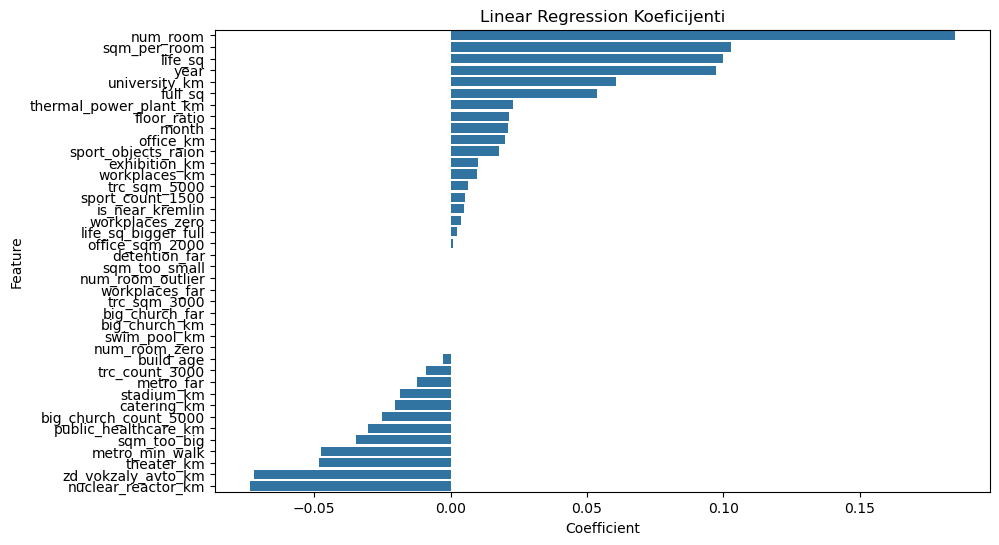

In [272]:
coefs = pipeline.named_steps["model"].coef_
features = pipeline.named_steps["preprocessor"].get_feature_names_out()

coef_df = pd.DataFrame({"Feature": features, "Coefficient": coefs})
coef_df = coef_df.sort_values(by="Coefficient", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Coefficient", y="Feature", data=coef_df)
plt.title("Linear Regression Koeficijenti")
plt.show()

Koeficijenti linearne regresije

Daje interpretabilnost: npr. full_sq, num_room, life_sq pozitivno utiču, dok udaljenost od nuclear_reactor_km, zd_vokzaly_avto_km negativno utiče.

Ovo je korisno za razumevanje šta model gleda, ali ne znači da daje dobre predikcije.

In [277]:
# num_preprocessor = create_preprocessor(nominal_cols, ordinal_cols, freq_cols, hight_corr_cols)

# X_train, X_test, y_train, y_test = return_train_test(df_hybrid3)

# pipeline = Pipeline(steps=[
#     ("preprocessor", num_preprocessor),
#     ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
# ])

# # param grid za RandomForest
# param_grid = {
#     "model__n_estimators": [100, 300],
#     "model__max_depth": [10, 20, None],
#     "model__min_samples_split": [2, 5],
#     "model__min_samples_leaf": [1, 2],
#     "model__max_features": ["sqrt", "log2"]
# }

# # GridSearchCV
# grid = GridSearchCV(
#     estimator=pipeline,
#     param_grid=param_grid,
#     cv=3,
#     scoring=rmsle_scorer,
#     n_jobs=-1,
#     verbose=2
# )

# # Fit
# grid.fit(X_train, y_train)

# print("Najbolji parametri:", grid.best_params_)
# print("Najbolji score (RMSLE):", grid.best_score_)

# # Finalna evaluacija na test setu
# best_model = grid.best_estimator_
# y_pred = best_model.predict(X_test)

# y_pred = unlog(y_pred)
# y_test_unlog = unlog(y_test)

# print("Evaluacija na test setu:")
# evaluate_regression(y_test_unlog, y_pred)


In [ ]:
# pipe = Pipeline(steps=[
#     ("preprocessor", num_preprocessor),  # isti preprocesor koji si već definisao
#     ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
# ])

# # Param distribucije (šire od grid-a)
# param_dist = {
#     "model__n_estimators": randint(100, 1000),        # broj stabala
#     "model__max_depth": [10, 20, 30, None],           # dubina stabala
#     "model__min_samples_split": randint(2, 20),       # minimalni split
#     "model__min_samples_leaf": randint(1, 10),        # minimalni list
#     "model__max_features": ["sqrt", "log2", None]     # broj feature-a po splitu
# }

# # RandomizedSearchCV
# rand_search = RandomizedSearchCV(
#     estimator=pipe,
#     param_distributions=param_dist,
#     n_iter=30,              # koliko kombinacija da proba
#     cv=3,                   # 3-fold cross validation
#     scoring=rmsle_scorer,   # custom RMSLE scorer
#     n_jobs=-1,
#     verbose=2,
#     random_state=42
# )

# # Fit
# rand_search.fit(X_train, y_train)

# print("Najbolji parametri:", rand_search.best_params_)
# print("Najbolji score (RMSLE):", rand_search.best_score_)

# # Finalna evaluacija na test setu
# best_model = rand_search.best_estimator_
# y_pred = best_model.predict(X_test)

# y_pred = unlog(y_pred)
# y_test_unlog = unlog(y_test)

# print("Evaluacija na test setu:")
# evaluate_regression(y_test_unlog, y_pred)


In [ ]:
print(len(rand_search.best_estimator_.named_steps["model"].feature_importances_))

In [ ]:
len(X_train.columns)

In [ ]:
# best_pipe = rand_search.best_estimator_
# preproc   = best_pipe.named_steps["preprocessor"]
# rf        = best_pipe.named_steps["model"]

# names = preproc.get_feature_names_out()
# imps  = rf.feature_importances_

# # sanity check
# print(len(names), len(imps), np.isclose(imps.sum(), 1.0))

# # TOP N tabela i plot
# feat_df = (pd.DataFrame({"Feature": names, "Importance": imps})
#            .sort_values("Importance", ascending=False))

# TOPN = 20
# plt.figure(figsize=(10,7))
# plt.barh(feat_df["Feature"].head(TOPN)[::-1], feat_df["Importance"].head(TOPN)[::-1])
# plt.xlabel("Feature importance")
# plt.ylabel("Feature")
# plt.title("Random Forest – Top feature importances")
# plt.tight_layout()
# plt.show()



In [ ]:
# pipe_best = rand_search.best_estimator_

# y_pred_log = pipe_best.predict(X_test)
# y_pred = unlog(y_pred_log)
# y_true = unlog(y_test)

# import numpy as np, matplotlib.pyplot as plt
# plt.figure(figsize=(7,5))
# plt.scatter(y_true, y_pred, alpha=0.4)
# m = [np.min([y_true, y_pred]), np.max([y_true, y_pred])]
# plt.plot(m, m, "r--", lw=2)        # idealna linija y=x
# plt.xlabel("Stvarne cene"); plt.ylabel("Predviđene cene")
# plt.title("Random Forest – Predikcija vs stvarno")
# plt.show()


Predikcija vs stvarne cene (ŷ naspram y)

Isprekidana linija je savršena pogodivost (ŷ = y).

Tačke su uglavnom ispod linije za skupe stanove → model sistematski potcenjuje visoke cene.

U nižem cenovnom rangu rasipanje je manje, pa tu pogadja bolje.
    
Bias: downward bias na „skupom repu“. Pomaže log-target, robustniji modeli i bolja obrada outliera.

In [ ]:
# resid = y_true - y_pred
# plt.figure(figsize=(7,5))
# plt.scatter(y_pred, resid, alpha=0.4)
# plt.axhline(0, color="r", linestyle="--")
# plt.xlabel("Predviđene cene"); plt.ylabel("Reziduali")
# plt.title("Random Forest – Reziduali vs Predikcije")
# plt.show()


Reziduali vs predikcije (r = y − ŷ naspram ŷ)

Oblik „levka“: varijansa reziduala raste sa predikcijom (heteroskedastičnost).

Mnogi pozitivni reziduali pri većim ŷ → potcenjivanje kada su cene visoke.
    
Dodatna obrada outliera, još feature-a koji objašnjavaju luksuz/centar, i/ili modeli koji bolje hvataju nelinearnosti.

In [281]:
# train_sizes, train_scores, val_scores = learning_curve(
#     pipe_best, X_train, y_train,
#     cv=3, scoring="r2",  # R² u log skali
#     train_sizes=np.linspace(0.2, 1.0, 6),
#     n_jobs=-1, shuffle=True, random_state=42
# )

# plt.figure(figsize=(7,5))
# plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Train R²")
# plt.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="CV R²")
# plt.xlabel("Broj uzoraka za treniranje"); plt.ylabel("R² (log)")
# plt.title("Random Forest – Learning curve")
# plt.legend(); plt.grid(alpha=0.3); plt.show()

Learning curve (R² na log-targetu)

Train R² visoko (0.74) i stabilno; CV R² znatno niži (0.40) ali raste sa više uzoraka.

Jasna varijanca (overfitting): model uči, ali bi mu koristilo još podataka i/ili jača regularizacija.
    
Probaj veći min_samples_leaf / min_samples_split, limit depth, više podataka ili ensembling (GBM/LightGBM/CatBoost).

In [ ]:
# pipe = Pipeline(steps=[
#     ("preprocessor", num_preprocessor),
#     ("model", RandomForestRegressor(
#         random_state=42, 
#         n_jobs=-1,
#         max_depth=6,
#         max_features='sqrt',
#         min_samples_leaf=10,
#         min_samples_split=5
#     ))
# ])

# pipe.fit(X_train,y_train)


# r2_train = r2_score(y_train, pipe.predict(X_train))
# r2_test  = r2_score(y_test, pipe.predict(X_test))

# print(f"Train R²: {r2_train:.4f}")
# print(f"Test  R²: {r2_test:.4f}")


In [285]:
# train_sizes, train_scores, val_scores = learning_curve(
#     pipe, X_train, y_train,
#     cv=3, scoring="r2",  # R² u log skali
#     train_sizes=np.linspace(0.2, 1.0, 6),
#     n_jobs=-1, shuffle=True, random_state=42
# )

# plt.figure(figsize=(7,5))
# plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Train R²")
# plt.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="CV R²")
# plt.xlabel("Broj uzoraka za treniranje"); plt.ylabel("R² (log)")
# plt.title("Random Forest – Learning curve")
# plt.legend(); plt.grid(alpha=0.3); plt.show()

In [ ]:
# pipe = Pipeline(steps=[
#     ("preprocessor", num_preprocessor),  # tvoj ColumnTransformer
#     ("model", xgb.XGBRegressor(
#         objective="reg:squarederror",  # za regresiju
#         tree_method="hist",            # brža obuka
#         random_state=42,
#         n_jobs=-1
#     ))
# ])


# param_dist = {
#     "model__n_estimators": [300, 600, 900],
#     "model__max_depth": [3, 6, 9, 12],
#     "model__learning_rate": [0.01, 0.05, 0.1, 0.3],
#     "model__subsample": [0.6, 0.8, 1.0],
#     "model__colsample_bytree": [0.6, 0.8, 1.0]
# }



# rand_search = RandomizedSearchCV(
#     estimator=pipe,
#     param_distributions=param_dist,
#     n_iter=30,
#     scoring=rmsle_scorer,
#     cv=3,
#     verbose=2,
#     n_jobs=-1,
#     random_state=42
# )


# rand_search.fit(X_train, y_train)

# print("Najbolji parametri:", rand_search.best_params_)
# print("Najbolji RMSLE score:", rand_search.best_score_)

# # Test set evaluacija
# best_model = rand_search.best_estimator_
# y_pred = best_model.predict(X_test)

# y_pred = unlog(y_pred)
# y_test_unlog = unlog(y_test)

# evaluate_regression(y_test_unlog, y_pred)  # Tvoja funkcija

In [ ]:
X_train, X_test, y_train, y_test = return_train_test(df_hybrid3)

pipe = Pipeline(steps=[
    ("preprocessor", num_preprocessor),  # mora imati samo numeričke/obradjene kolone
    ("model", xgb.XGBRegressor(
    objective="reg:squarederror",  # regresija
    tree_method="hist",            # brže treniranje
    random_state=42,
    n_jobs=-1,
    # tvoji pronađeni hiperparametri:
    subsample=0.8,
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    colsample_bytree=1.0
    ))
])

# Cross-val predikcije (log space)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = cross_val_predict(pipe, X_train, y_train, cv=cv, n_jobs=-1)

In [ ]:
evaluate_regression(y_train, oof_preds)

In [ ]:
plt.figure(figsize=(7,7))
sns.scatterplot(x=y_train, y=oof_preds, alpha=0.5)
plt.xlabel("log(y_true)")
plt.ylabel("log(y_pred)")
plt.title("OOF log-log preds vs ground truth")
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         linestyle='--', color='red')  # idealna linija
plt.grid()
plt.tight_layout()
plt.show()


In [ ]:
param_dist = {
    "model__n_estimators": [300, 600, 900],
    "model__max_depth": [3, 6, 9, 12],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.3],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0]
}

rand_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring=rmsle_scorer,
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

rand_search.fit(X_train, y_train)
best_model = rand_search.best_estimator_

In [ ]:
y_pred = best_model.predict(X_test)

# Unloguj rezultat
y_pred = np.expm1(y_pred)
y_true = np.expm1(y_test)

# Evaluacija
print("RMSLE:", rmsle(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("R2:", r2_score(y_true, y_pred))


In [ ]:
plt.figure(figsize=(7,7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.xlabel("log(y_true) [test]")
plt.ylabel("log(y_pred) [test]")
plt.title("Test set: log-log preds vs ground truth")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--', color='green')  # idealna linija
plt.grid()
plt.tight_layout()
plt.show()


In [ ]:
print(y_pred)

In [ ]:
base_estimators = [
    ("xgb", XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        n_jobs=-1,
        random_state=42
    )),
    ("lgb", LGBMRegressor(
        objective="regression",
        boosting_type="gbdt",
        n_jobs=-1,
        random_state=42
    )),
    ("ridge", RidgeCV(alphas=(0.1, 1.0, 10.0)))
]
final_estimator = RidgeCV(alphas=(0.1, 1.0, 10.0))


In [ ]:
df["price_doc_log"].head()

In [ ]:
stacking_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=final_estimator,
    passthrough=True,  # ako hoćeš da svi prediktori dobiju originalne feature-e
    n_jobs=-1,
    cv=5
)

preprocessor = create_preprocessor(nominal_cols, ordinal_cols, freq_cols, hight_corr_cols)

X_train, X_test, y_train, y_test = return_train_test(df_hybrid3)

model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("stacking", stacking_model)
])


In [ ]:
# Pretvori sve u numpy ako već nisu
y_test_arr = np.array(y_test)
y_pred_arr = np.array(y_pred)

# Maskiraj gde nije NaN
mask = (~np.isnan(y_test_arr)) & (~np.isnan(y_pred_arr))

# Ocene
mse = mean_squared_error(y_test_arr[mask], y_pred_arr[mask])
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_arr[mask], y_pred_arr[mask])
r2 = r2_score(y_test_arr[mask], y_pred_arr[mask])

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.4f}")


In [ ]:
print(y_test.isna().sum().sum())

In [ ]:
y_pred

In [ ]:
evaluate_regression(unlog(y_test), y_pred)

In [ ]:
stacking_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=RidgeCV()
)

model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("stacking", stacking_model)
])

model_pipeline.fit(X, y)
 # trenirani meta-model

In [ ]:
meta = model_pipeline.named_steps["stacking"].final_estimator_
print(meta)


In [ ]:
print(model_pipeline.named_steps["stacking"].final_estimator_.coef_)


In [307]:


X_train, X_test, y_train, y_test = return_train_test(df_hybrid3)

price = unlog(y_train)     
w = 1 / np.sqrt(price)

num_preprocessor = create_preprocessor(nominal_cols, ordinal_cols, freq_cols, hight_corr_cols)

pipe = Pipeline(steps=[
    ("preprocessor", num_preprocessor),  # mora imati samo numeričke/obradjene kolone
    ("model", xgb.XGBRegressor(
    objective="reg:squarederror",  # regresija
    tree_method="hist",            # brže treniranje
    random_state=42,
    n_jobs=-1,
    # tvoji pronađeni hiperparametri:
    subsample=0.8,
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    colsample_bytree=1.0
    ))
])

pipe.fit(
    X_train, 
    y_train,
    model__sample_weight=w
)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('preprocess', ...), ('quantile', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('nominal', ...), ('ordinal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3


In [ ]:
evaluate_regression(unlog(y_test), y_pred)

In [309]:
# === Target 1: log(price_doc) ===
df1 = df_hybrid3.copy()
df1 = df1[df1["price_doc"].notna() & df1["full_sq"].notna()]

df1["y_log_price"] = np.log(df1["price_doc"])

X1 = df1.drop(columns=["price_doc", "y_log_price"])
y1 = df1["y_log_price"]

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

pipe.fit(X1_train, y1_train)
y1_pred = pipe.predict(X1_test)

rmsle_price = np.sqrt(mean_squared_log_error(np.exp(y1_test), np.exp(y1_pred)))
print("RMSLE (log price_doc):", rmsle_price)


# === Target 2: log(price_per_m2) ===
df2 = df_hybrid3.copy()
df2 = df2[df2["price_doc"].notna() & df2["full_sq"].notna() & (df2["full_sq"] > 0)]

df2["price_per_m2"] = df2["price_doc"] / df2["full_sq"]
df2["y_log_price_m2"] = np.log(df2["price_per_m2"])

X2 = df2.drop(columns=["price_doc", "price_per_m2", "y_log_price_m2"])
y2 = df2["y_log_price_m2"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

pipe.fit(X2_train, y2_train)
y2_pred = pipe.predict(X2_test)

C:\Users\aleks\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


RMSLE (log price_doc): 0.45720741089406414


C:\Users\aleks\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [311]:
evaluate_regression(unlog(y1_test),unlog(y1_pred))

MSE:  8094028072740.065
RMSE:  2845000.5400245646
MAE:  1747215.241711392
R²:  0.6254510921101212
RMSLE:  0.4572075673441255


{'MSE': 8094028072740.065,
 'RMSE': 2845000.5400245646,
 'MAE': 1747215.241711392,
 'R²': 0.6254510921101212,
 'RMSLE': 0.4572075673441255}

In [313]:
evaluate_regression(unlog(y2_test),unlog(y2_pred))

MSE:  2052529150.7991812
RMSE:  45304.84687976752
MAE:  31897.8512596509
R²:  0.3178867839478102
RMSLE:  0.4569715135453995


{'MSE': 2052529150.7991812,
 'RMSE': 45304.84687976752,
 'MAE': 31897.8512596509,
 'R²': 0.3178867839478102,
 'RMSLE': 0.4569715135453995}